# Multiple comparison correction \(MCC\) and region of interest \(ROI\) analysis

In this notebook, we'll continue with the topic of multiple comparison correction \(MCC\) and region of interest \(ROI\) analysis.

**What you'll learn**: after this lab, you'll ...

- know the relative advantages and disadvantages of different MCC techniques
- understand and implement ROI\-based analyses \(in Python\)

**Estimated time needed to complete**: 1.5 hours<br>
**Credits**: This notebook is based on a blog by [Matthew Brett](https://matthew-brett.github.io/teaching/random_fields.html) and a previous Matlab\-based lab by H. Steven Scholte.


In [5]:
import os
import urllib.request

def download_file(url, outfile):
    """Download file from URL if not already present."""
    if not os.path.exists(outfile):
        print(f"Downloading {outfile}...")
        urllib.request.urlretrieve(url, outfile)
        print(f"Saved as {outfile}")
    else:
        print(f"{outfile} already exists, skipping download.")

# Downloading some required data
download_file(
    "https://www.dropbox.com/scl/fi/kcuss11sgdfcr9vnsvs7d/amygdala_lat-right_atlas-harvardoxford_thresh-0.nii.gz?rlkey=6g1iyo1mk7v2h5e9ttl1l9uae&dl=1",
    "amygdala_lat-right_atlas-harvardoxford_thresh-0.nii.gz"
)

download_file(
    "https://www.dropbox.com/scl/fi/fdnlp8bh3i2w30hkjcpf9/clust_size_dist_data.npz?rlkey=47tvz2x384fku8dljbzenwg53&dl=1",
    "clust_size_dist_data.npz"
)

download_file(
    "https://www.dropbox.com/scl/fi/cyalx7ikknswxci0p219d/contrast-faceGTother_level-group_stat-zstat.nii.gz?rlkey=u4e49ivtu89btkc3i0ozhfb9o&dl=1",
    "contrast-faceGTother_level-group_stat-zstat.nii.gz"
)

download_file(
    "https://www.dropbox.com/scl/fi/ycwdttpnl0ip87rz2p8um/cute_cat.jpeg?rlkey=8tcpz2r5v2b4temlyyk6qv0y0&dl=1",
    "cute_cat.jpeg"
)

download_file(
    "https://www.dropbox.com/scl/fi/9k2z7ktrxbggb21u22c3b/fdr.py?rlkey=yxifjjfpyaic37aizgqhrtj6v&dl=1",
    "fdr.py"
)

download_file(
    "https://www.dropbox.com/scl/fi/pqzbgqra94u3collpj3is/perms.npy?rlkey=v4qz26vh0iivk21jrjhbtpyow&dl=0",
    "perms.npy"
)


amygdala_lat-right_atlas-harvardoxford_thresh-0.nii.gz already exists, skipping download.
clust_size_dist_data.npz already exists, skipping download.
contrast-faceGTother_level-group_stat-zstat.nii.gz already exists, skipping download.
cute_cat.jpeg already exists, skipping download.
fdr.py already exists, skipping download.
perms.npy already exists, skipping download.


In [6]:
download_file("https://www.dropbox.com/scl/fi/zxsds8xi1sg9xn2ymkl66/contrast-faceGTother_level-run_stat-cope.nii.gz?rlkey=2mo4ja1p9vjz1dqvh8dc5m5vx&dl=1", "contrast-faceGTother_level-run_stat-cope.nii.gz")

contrast-faceGTother_level-run_stat-cope.nii.gz already exists, skipping download.


## Why do we need MCC?
Univariate analyses of fMRI data essentially test hypotheses about your data (operationalized as contrasts between your $\hat{\beta}$ estimates) *for each voxel* separately. So, in practice, given that the MNI (2 mm) standard template brain contains about 260,000 voxels, you're conducting 260,000 different statistical tests! The obvious problem, here, is that some tests might turn out significant, while they in fact do not contain any (task-related) activity: the result is driven just by chance.

As a researcher, you should strive to "filter out" the results which are driven by noise (*false positives*) and keep the results which are actually driven by the true effect (*true positives*) as much as possible. It turns out that the more tests you do, the larger the chance is that you will find one or more *false positives*. To deal with this, researchers often employ techniques for *multiple comparison correction* (MCC): **correcting** for the inflated chance of false positives when you have **multiple** tests (**comparisons**).

In this tutorial, we will walk you through an example (simulated) dataset on which different MCC techniques are employed. We'll focus on how these different techniques influence the chance for finding false positives.

### The example

We'll work with the (simulated) group-level results of a hypothetical fMRI experiment. Suppose that the subjects in our hypothetical experiment were shown pictures of cats in the scanner, because we (the experimenters) were interested in which voxels would (de)activate significantly in reponse to these cat pictures (i.e. a contrast of the cat-picture-condition against baseline).

An example of an image shown to the subjects:
![test](cute_cat.jpeg)

After extensive preprocessing, we fitted first-level models in which we evaluated the cat-against-baseline contrast, in which the $t$-statistic refers to how strongly each voxel responded to the pictures of cats. After doing a proper group-level analysis, we now have a group-level $t$-statistic map, reflecting whether voxels on average (de)activated in response to the pictures of cats.  



<div class='alert alert-info'>
<b>ToThink</b> (0.5 point): On average, what group-level $t$-statistic would you (approximately) expect to find if, in fact, there would be no voxel which reliably (de)activated in response to the cat-pictures?
</div>

If no voxel reliably \(de\)activated in response to the cat pictures, we would expect the group level t statistic to be 0.


## The data
Usually, your whole-brain group-level results are 3D $z$- or $t$-statictic maps of the size of a standard brain (usually the MNI 2mm template, which has about 260,000 voxels). Plotting in 3D, however, is incredibly cumbersome, so for the sake of the example, we'll assume that our group-level results are represented as a 2D $z$-statistic map, with dimensions $200 \times 200$. So, we'll pretend we analyzed the results based on a 2D brain with $200 \times 200$ "voxels". 

Because we work with simulated data, we can actually specify the "true effect". In reality, we never know this of course! We are going to assume that there is a small "blob" of voxels in the middle of our "brain" that activates reliably to pictures of cats (with a $z$-value of 5.5). This blob is therefore the true effect in our simulation. 

Let's first simulate the data.

In [7]:
import numpy as np

# You don't have to understand how this simulation works exactly
k = 200  # number of vox in each dimension
signal = np.zeros((k, k))
r = 10  # middle of the image
a, b = k // 2, k // 2  # width and height of the circle
y, x = np.ogrid[-a:k-a, -b:k-b]
mask = x * x + y * y <= r * r
signal[mask] = 5.5  # amplitude of effect!

print("Shape of statistic map: %s" % (signal.shape,))

Shape of statistic map: (200, 200)


Alright, now let's plot the true effect as a 2D image. We'll define a custom function for this, `plot_sim_brain`, to save us some work later.

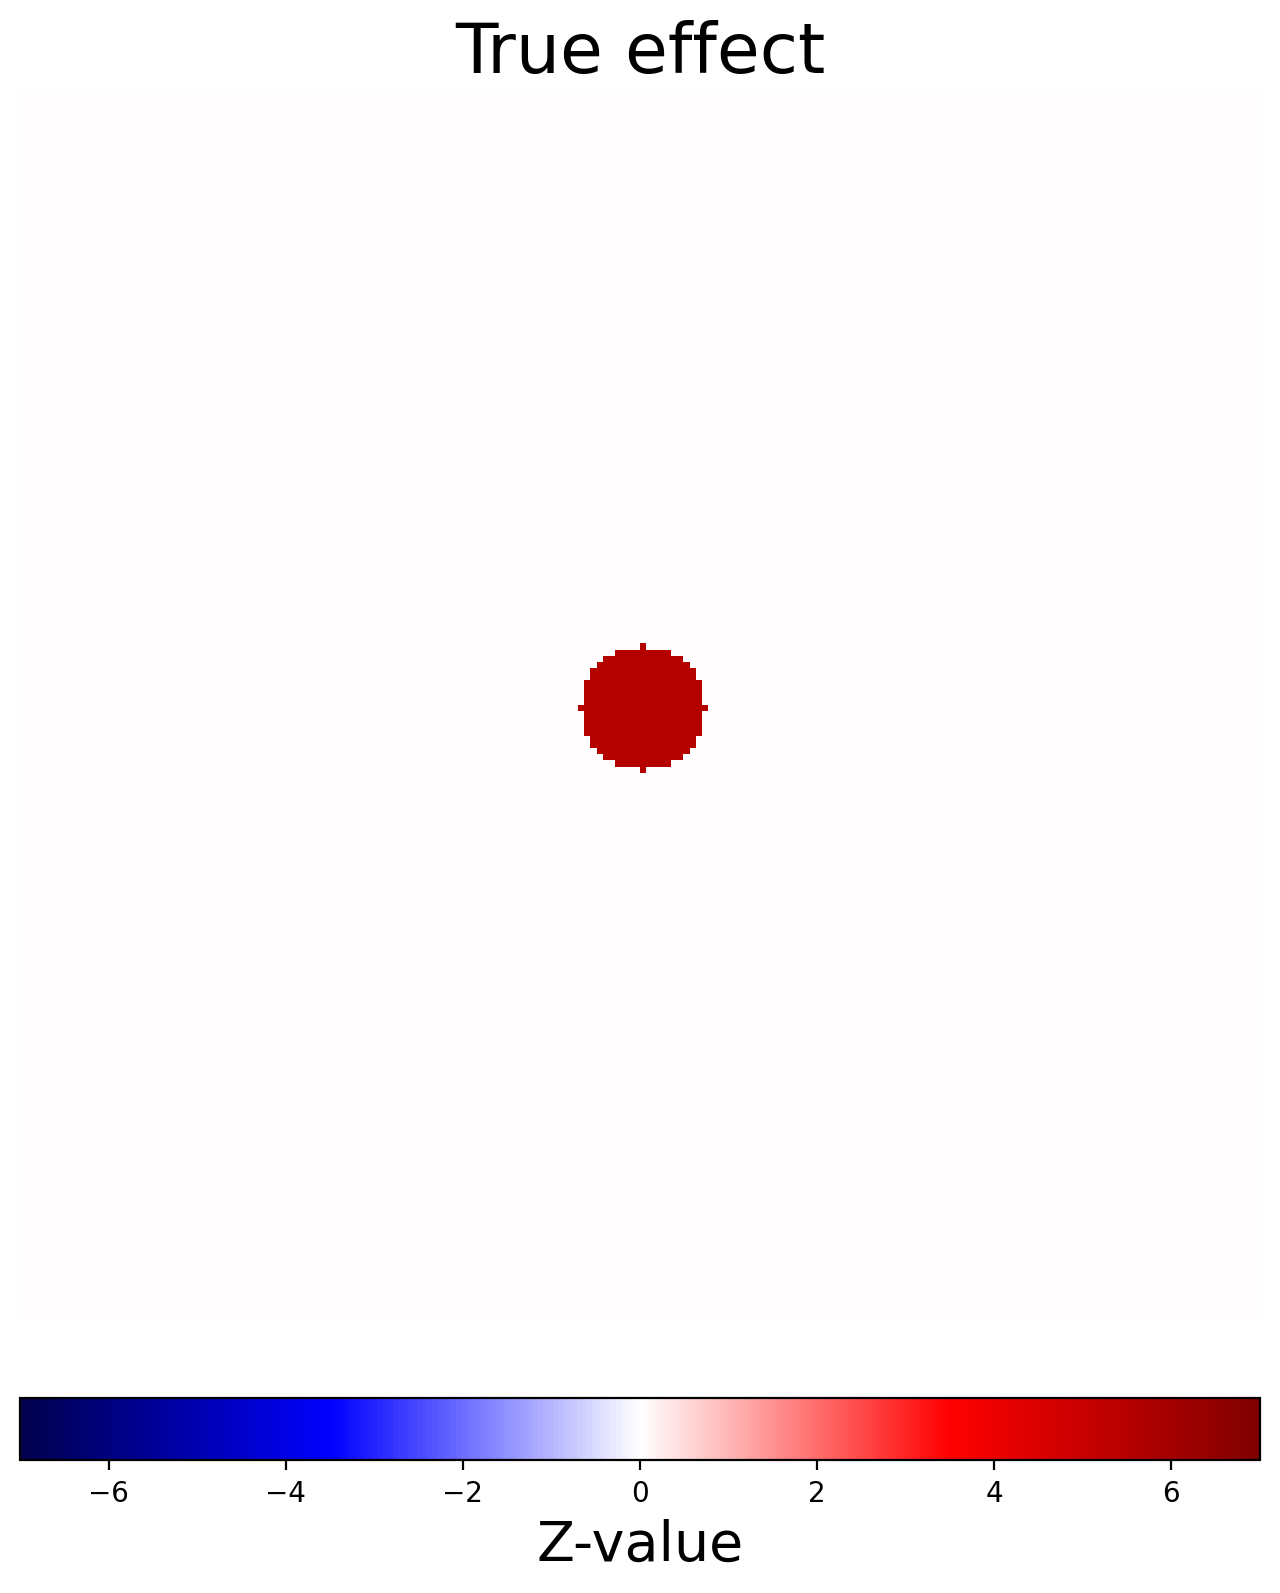

In [8]:
import matplotlib.pyplot as plt

def plot_sim_brain(brain, mask=None, vmin=-7, vmax=7, cmap='seismic', title='', label='Z-value'):
    """ Plots an image of a simulated 2D 'brain' with statistic values, which may be 'masked'.
    
    Parameters
    ----------
    brain : numpy array
        A 2D numpy array with statistics
    mask : numpy array (or None)
        A 2D numpy array with booleans (True = do plot, False = do not plot). If None,
        the 'brain' is not masked.
    vmin : int/float
        Minimum value of colorbar
    vmax : int/float
        Maximum value of colorbar
    cmap : str
        Name of colormap to use
    title : str
        Title of plot
    label : str
        Label for colorbar
    """
    
    brainm = brain.copy()
    if mask is not None:  # threshold!
        brainm[~mask] = 0

    plt.figure(figsize=(8, 10))
    plt.imshow(brainm, vmin=vmin, vmax=vmax, aspect='auto', cmap=cmap)
    plt.axis('off')
    plt.title(title, fontsize=25)
    
    cb = plt.colorbar(orientation='horizontal', pad=0.05)
    cb.set_label(label, fontsize=20)
    plt.show()
    
plot_sim_brain(signal, title="True effect")

Now, due to the inherent spatial smoothness of fMRI, this particular manifestation of the effect is not very realistic. In particular, the sharp "edges" of the effect are unlikely to occur in real fMRI data. Therefore, to make it a little more realistic, we can spatially smooth the "true effect map"! We will use the `gaussian_filter` function (from `scipy.ndimage`) with a FWHM of 12 "voxels". 

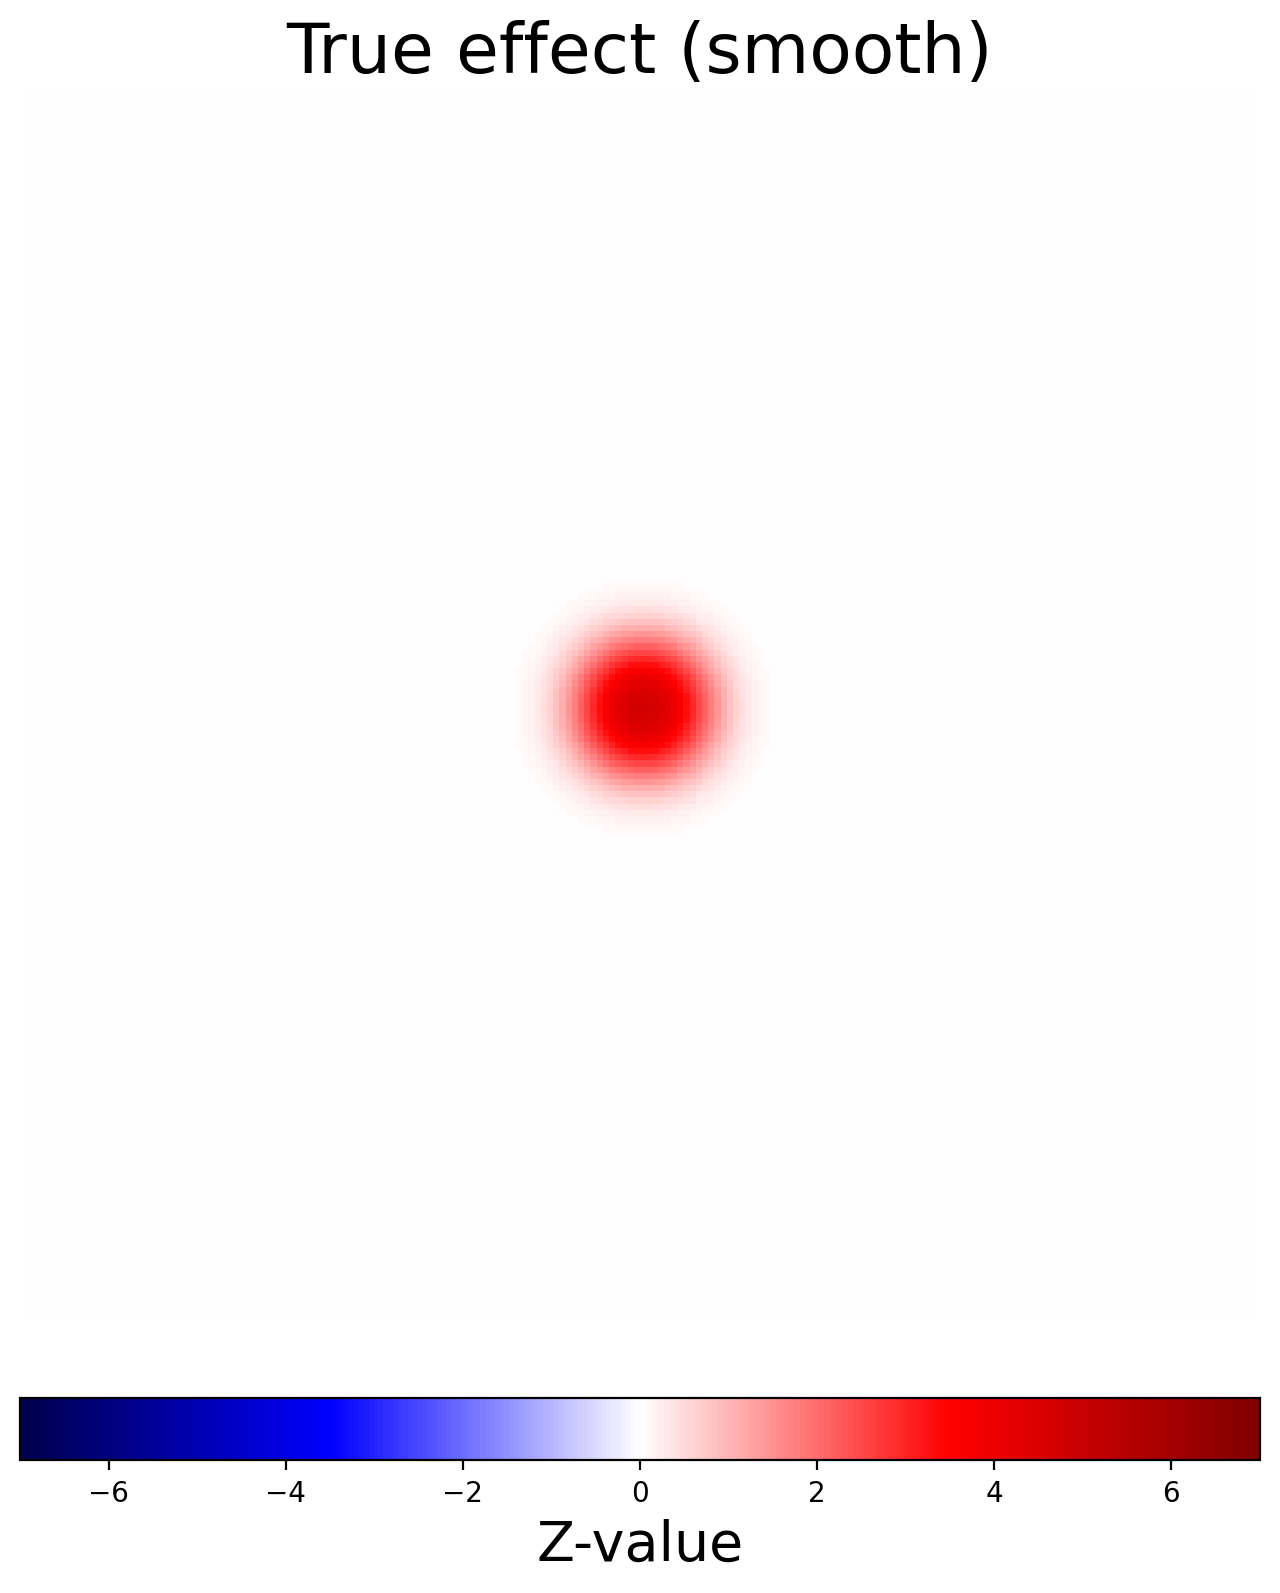

In [9]:
from scipy.ndimage import gaussian_filter

fwhm = 12
# Convert FWHM to sigma
sigma = fwhm / np.sqrt(8 * np.log(2))
signal_smooth = gaussian_filter(signal, sigma=sigma)
plot_sim_brain(signal_smooth, title="True effect (smooth)")

As you've learned in the past weeks, the chances are very slim that you'll find such a "crisp" (true) effect as shown above; often, you might observe significant voxels that are not driven by a true effect, but by (spurious) noise, reflecting false positives.

So, let's make our data a little more realistic by simulating some random noise, sampled from a normal distribution with mean 0 and a standard deviation of 1. Importantly, we are also going to smooth our noise with the same gaussian filter (with FWHM = 12): 

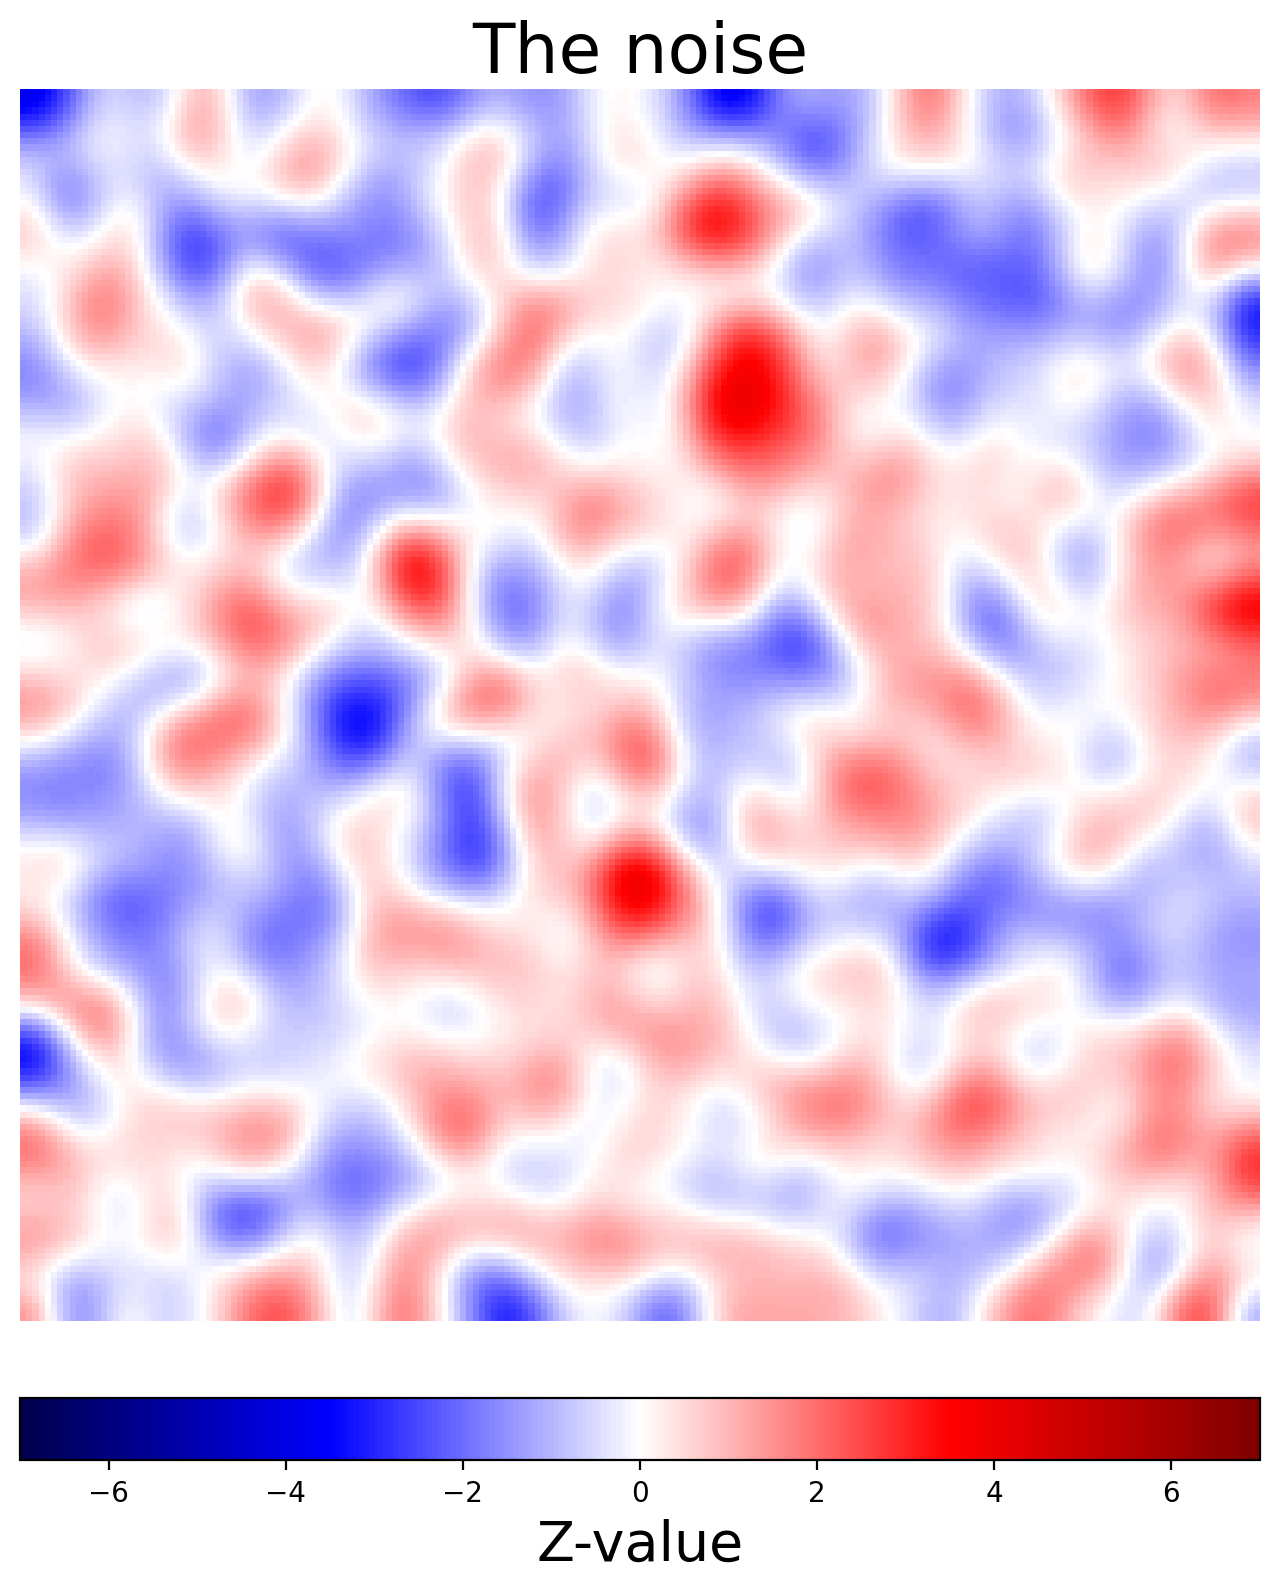

In [10]:
np.random.seed(2)  # for reproducibility
noise = np.random.normal(0, 1, size=signal.shape)
noise = gaussian_filter(noise, sigma=sigma)
noise = noise / noise.std()

plot_sim_brain(noise, title='The noise')

Now, to complete our simulation, we'll simply add the signal and the noise together (we'll call this variable `data`).

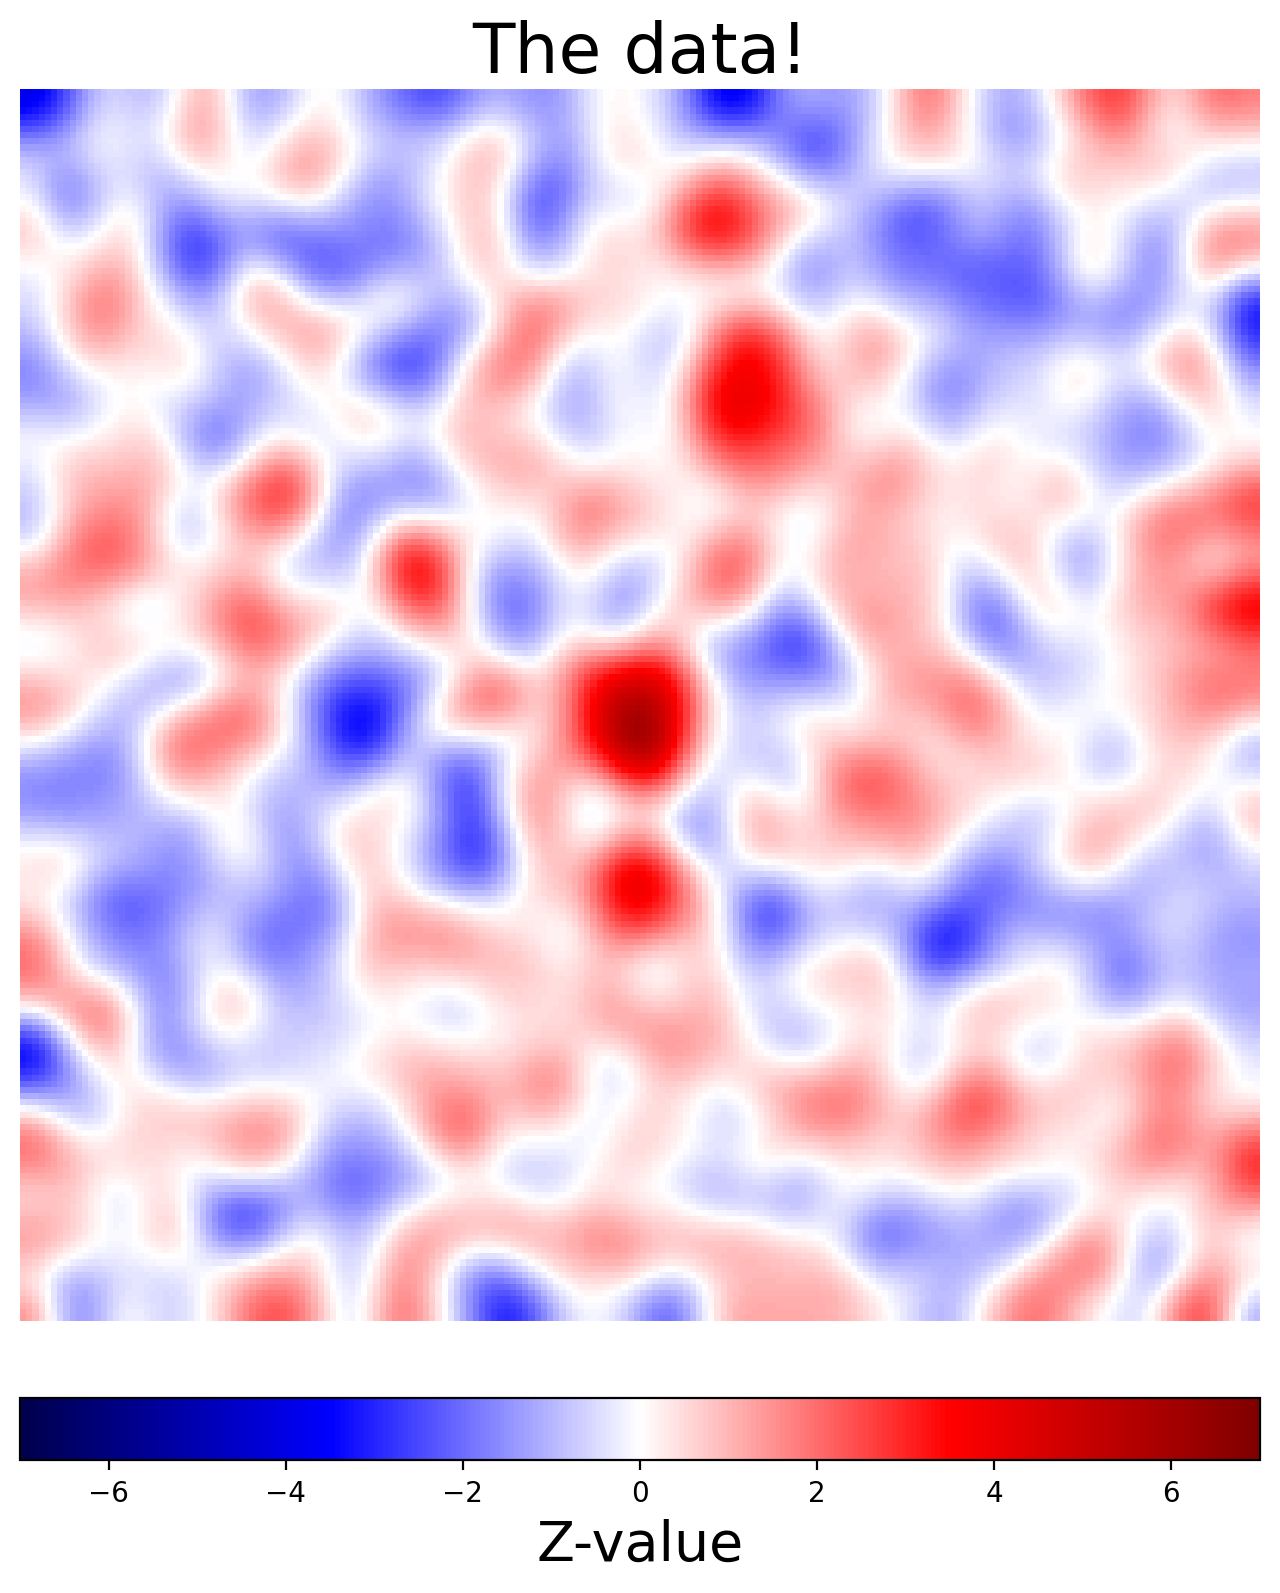

In [11]:
data = signal_smooth + noise
plot_sim_brain(data, title='The data!')

The plot above now represents our simulated data, which contains both a true signal (the "blob" in the middle) and some (spatially correlated) noise. As a researcher, you aim to threshold your data in such a way that you maximize the chance of finding your true signal (true positive effects) and minimize the chance of erroneously treating noise as significant effects (false positive effects).

## Uncorrected statistics maps
In the early days of fMRI analyses, the extent of the MCC problem (more tests = more false positives) was not yet widely known. What researchers simply did was to calculate the $p$-values corresponding to the $z$-value (or $t$-value) maps and threshold those $p$-values using some fixed cutoff ("alpha value"), usually 0.05 or 0.01. 

To implement this, we can convert all our $z$-values to $p$-values, compute a "mask" (i.e., an array with `True` and `False` values, indicating which "voxels" survive the threshold and which do not), and set all "voxels" outside the mask to 0. 

Let's choose a significance level ($\alpha$) of 0.05.

In [12]:
alpha = 0.05

Now, let's convert the $z$-values (in the variable `data`) to $p$-values. We'll use the `stats.norm.sf` function from the `scipy` package for this. (This is the same type of function &mdash; a "survival function" &mdash; that we used to calculate the $p$-values corresponding to $t$-values before, but this time we use it for $z$-values)

In [13]:
# This line converts the z-values to p-values
from scipy import stats

data_pvals = stats.norm.sf(data)

<div class='alert alert-warning'>
    <b>ToDo</b> (1 point): Compute how many voxels are deemed to be "significant" (assuming $\alpha = 0.05$), using the variable <tt>data_pvals</tt>, in this approach in which we neglect the multiple comparison approach. Store this number (an integer) in a new variable named <tt>nsig_uncorrected</tt>.
</div>



In [12]:
# Implement your ToDo here

# YOUR CODE HERE
nsig_uncorrected = np.sum(data_pvals < 0.05)
# raise NotImplementedError()

In [13]:
# Feedback cell: nsig_uncorrected

if 'nsig_uncorrected' not in locals():
    print('The variable "nsig_uncorrected" is not defined. Did you assign it using the correct name?')
elif not np.isscalar(nsig_uncorrected):
    print('The variable "nsig_uncorrected" should be a single integer, not an array.')
elif nsig_uncorrected < 0:
    print('The number of significant voxels cannot be negative.')
else:
    print('Your answer passed basic automated checks.')

Your answer passed basic automated checks.


We can create a "mask" by comparing our $p$-values to our significance level and we can give this mask to our plotting-function (`plot_sim_brain`), which will set all "voxels" outside the mask (i.e., those which are `False` in the mask) to 0. 

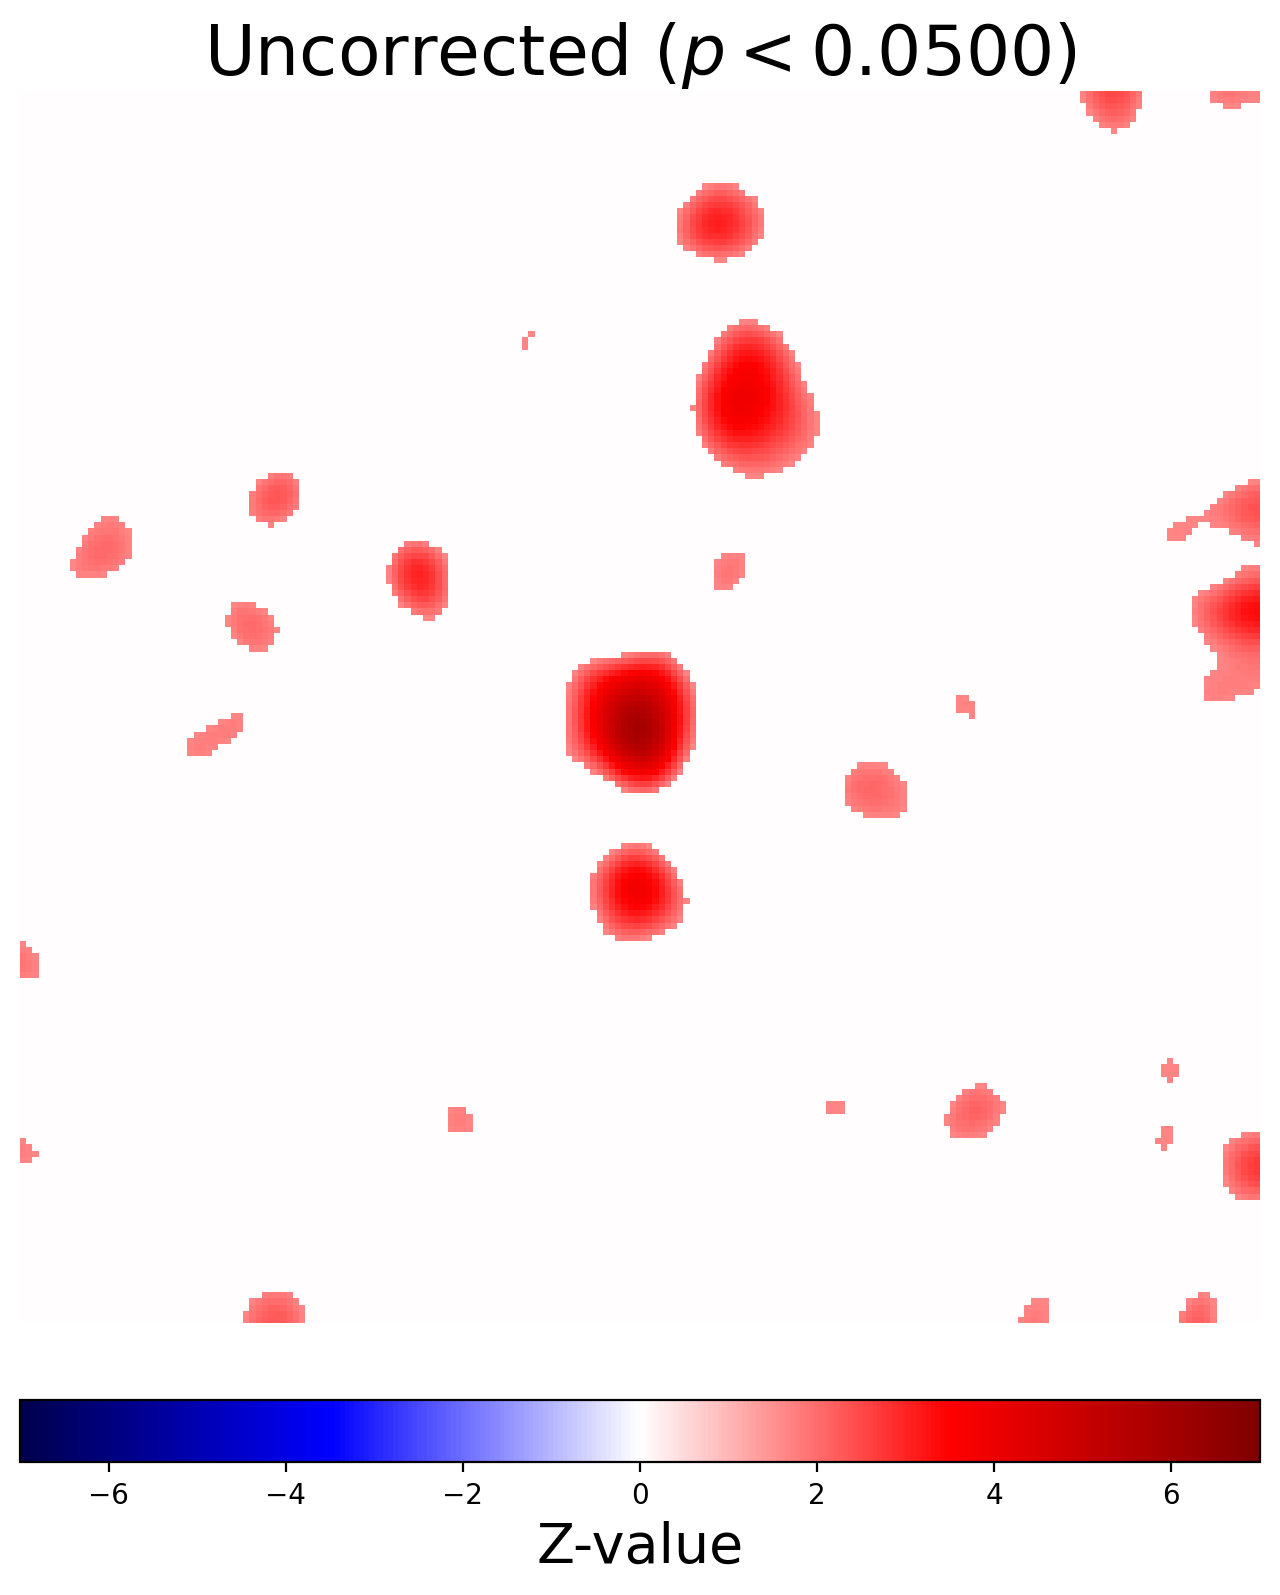

In [14]:
smaller_than_alpha = data_pvals < alpha
# Note that 'smaller_than_alpha' is a 2D numpy array with booleans

plot_sim_brain(data, mask=smaller_than_alpha, title=r'Uncorrected ($p < %.4f$)' % alpha)

<div class='alert alert-warning'>
    <b>ToDo/ToThink</b> (1 point): Change the value of $\alpha$ (i.e., the variable <tt>alpha</tt>) from before to 0.01. Does the resulting thresholded map look "better"? And what about 0.001? And 0.0001? Theoretically, you could try different values to see what gives the "best" results. This practice of trying out different parameters or strategies leads to another problem: can you think of what this could be? Write down your answer below.
</div>

Changing the alpha to more extreme values, like 0.01, 0.001 or 0.001 certainly makes the threshold map look cleaner \(or "better"\) and less noisy, i.e., we have removed the activation points that were likely false positives. The more extreme the alpha value, the cleaner the map because fewer activated voxels pass the threshold. 

However, decreasing the alpha value does not solve the multiple comparisons problem, and it's also possible that voxels showing the "true" signal that we are interested in measuring may be wiped out by the high threshold. 


## Bonferroni-correction
Obviously, given that we know our "true effect", we can see that the uncorrected results contain *a lot* of false positives, something that we'd like to avoid! The most obvious way to counter the MCC problem is to adjust the significance level ($\alpha$) by the amount of tests we're performing. Bonferroni correction is such an approach. The way the Bonferroni method does this is by simply dividing the significance level by the amount of tests.

<div class='alert alert-warning'>
<b>ToDo</b> (1 point): Calculate the Bonferroni-adjusted significance level (and store this in a variable named <tt>bonf_alpha</tt>) and create a new mask by comparing the previously computed $p$-values against this new significance level. Then, plot the data (using <tt>plot_sim_brain</tt>) with the mask you just created.
</div>



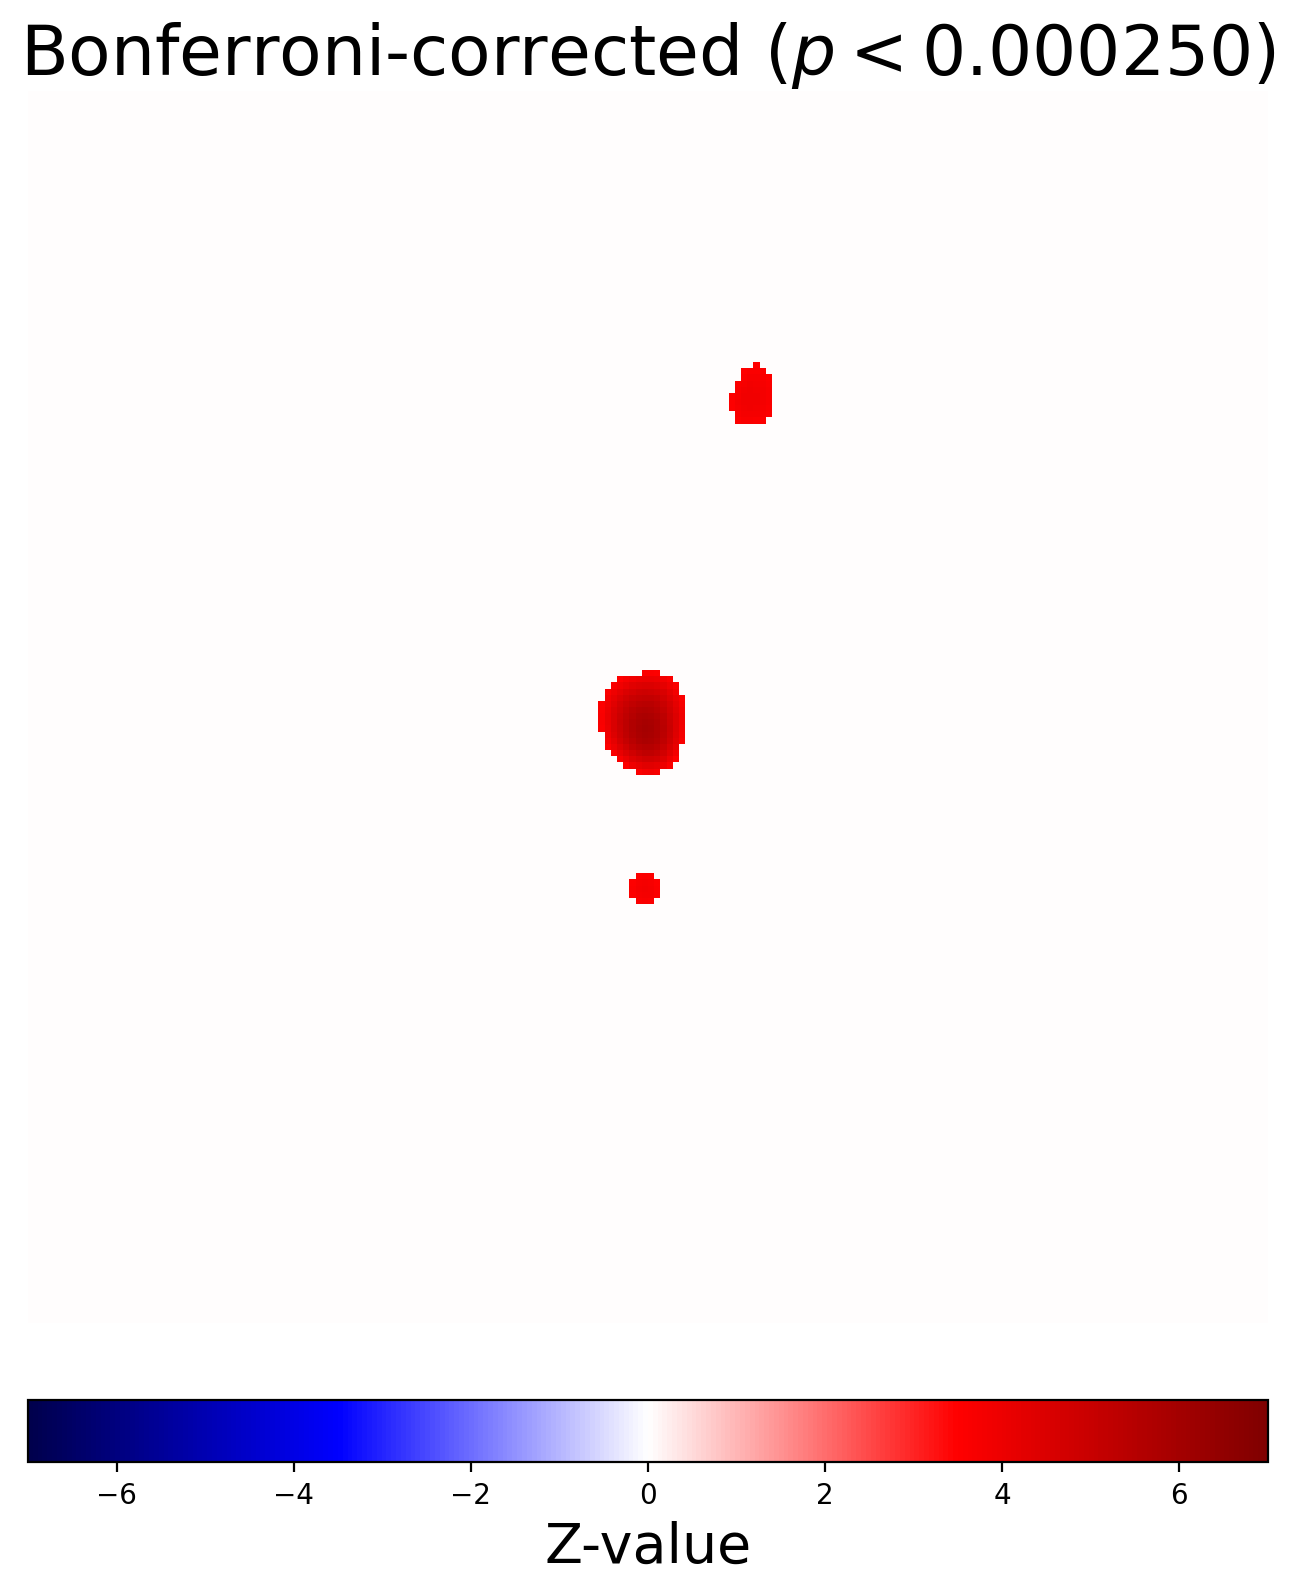

In [15]:
# Implement your ToDo here. The Bonferroni-adjusted significance level will be graded automatically and the plot will be graded manually

# YOUR CODE HERE

# Bonferroni-adjusted significance level
bonf_alpha = alpha / len(data_pvals)

# Bonferroni-adjusted mask
smaller_than_bonf = data_pvals < bonf_alpha

# plotting Bonferroni-adusted result
plot_sim_brain(
    data,
    mask=smaller_than_bonf,
    title=r'Bonferroni-corrected ($p < %.6f$)' % bonf_alpha
)
# raise NotImplementedError()

In [16]:
# Feedback for bonf_alpha
if 'bonf_alpha' not in locals():
    print('The variable "bonf_alpha" is not defined. Make sure you compute the Bonferroni-adjusted significance level.')
elif not np.isscalar(bonf_alpha):
    print('The variable "bonf_alpha" should be a single number, not an array.')
elif bonf_alpha <= 0 or bonf_alpha > alpha:
    print('The value of bonf_alpha looks wrong. Remember it should be alpha divided by the number of tests.')
else:
    print('Your Bonferroni-adjusted alpha looks good!')


Your Bonferroni-adjusted alpha looks good!


<div class='alert alert-info'>
<b>ToThink</b> (not graded): Many argue that Bonferroni correction for whole-brain fMRI results is too strict (conservative), which is also the case in our simulation (the recovered "blob" is a lot smaller than the true effect). This conservative nature of Bonferroni correction, for fMRI at least, is due to the violation of a crucial assumtion of Bonferroni correction. Which assumption is this, and why does fMRI data/results likely violate this assumption?
</div>

<details>
  <summary>Show answer</summary>

Bonferroni correction assumes that all tests are independent of each other. In fMRI data, this assumption is violated because neighboring voxels are highly spatially correlated, meaning activation in one voxel is not independent of activation in nearby voxels. By testing one voxel, I'm quite certain that the voxel next to it is going to give similar results. Therefore, Bonferroni correction is usually too strict for fMRI data and will lead to a relatively high amount of false negatives.

</details>



## FDR correction
As you've seen so far, uncorrected results tend to be too liberal (too many false positives) and Bonferroni-corrected results are too strict (too many false negatives). The "False Discovery Rate-correction" (FDR) technique is a method to adjust $p$-values in a less stringent way. Essentially, while traditional MCC methods (such as Bonferroni) try to control the chance of finding at least one false positive result **amongst all your tests** (i.e. controlling the "familywise error rate" method), the FDR-method tries to limit the proportion of false positives **amongst all your tests which turned out significant**. So, if you set your "FDR-proportion" (confusingly also referred to as "alpha") to 0.05, then it will adjust your initial $p$-values such that out of all your significant results, on average 5% will be false positives.  

In general, FDR-correction is more sensitive than the Bonferroni correction method (i.e. FDR has a lower type 2 error rate/it is less strict), but if you use it, you *do* have to accept that about 5% of your (significant) results are false positives!

Now, let's check out what our results look like after FDR correction:

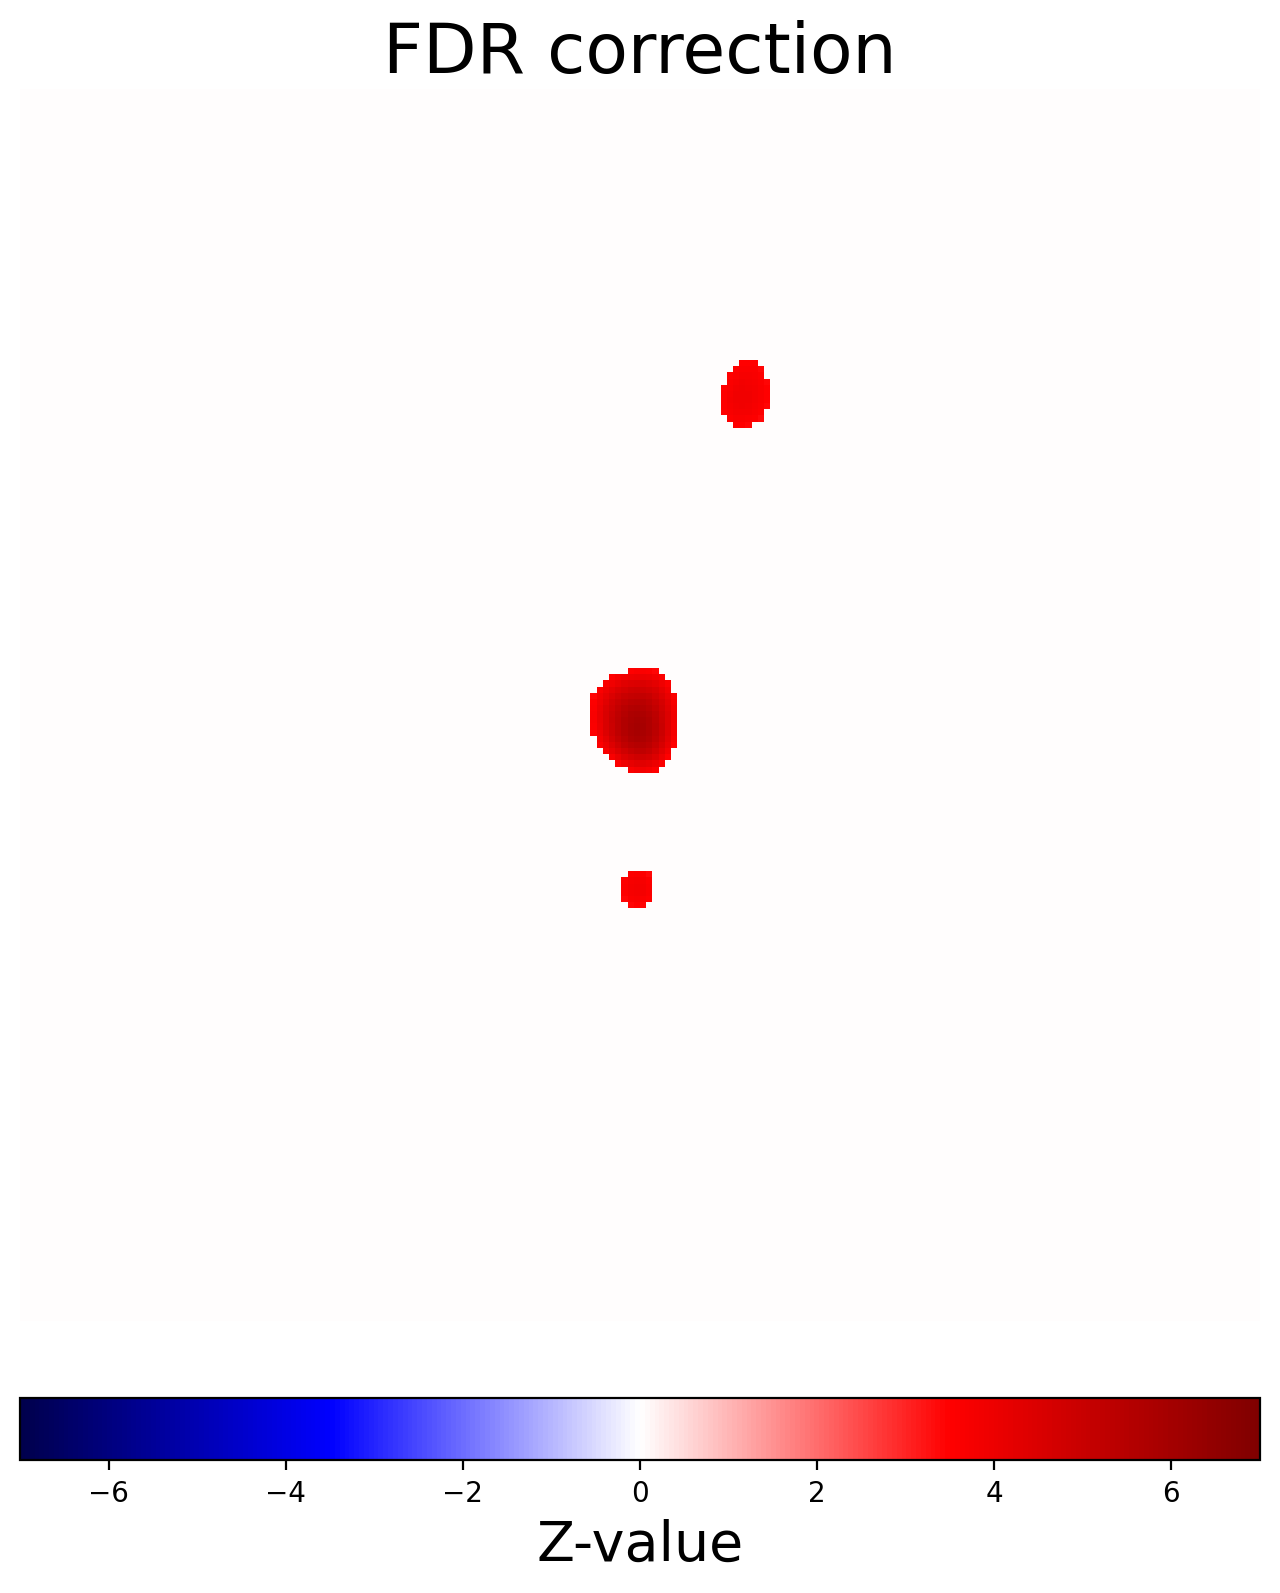

In [17]:
# fdr implementation from statsmodels package
from fdr import fdrcorrection
alpha_fdr = 0.05 # we use an alpha of 0.05 (5%)

# The fdrcorrection function already returns a "mask"
# Note that it doesn't accept 2D arrays, so we ravel() and then reshape() it
fdr_mask = fdrcorrection(data_pvals.ravel(), alpha=alpha_fdr)[0]
fdr_mask = fdr_mask.reshape(data.shape)

plot_sim_brain(data, mask=fdr_mask, title='FDR correction')

As you can see, the FDR-correction is way more sensitive than the Bonferroni correction (it "recovers" more of the true signal), but it still results in many false positives (but not as many as uncorrected data).



## RFT-based correction

As you've seen in the previous examples, it's quite hard to pick a significance level that strikes a good balance between type 1 errors and type 2 errors, or, phrased differently, between sensitivity (with respect to discovering the true signal) and specificy (i.e. how many of our significant voxels are driven by a true effect).

Let's go back to the results of the Bonferroni correction. We've seen that the results are extremely conservative (few false positives, but many false negatives, i.e. large type 2 error). The major reason for this is that the correction assumes that each test is *independent*, but in our simulation (and in any fMRI dataset), we *know* that there exists spatial correlation, meaning that our tests are *not* independent. In other words, if we know that a certain voxel is signficant in a certain test, it is quite likely that the voxel directly *next* (or above/below) to it is also significant. Therefore, spatially correlated fMRI statistic maps violate Bonferroni's assumption of independent tests (this is also the answer to the ToThink from earlier).

As a possible solution to this problem, neuroscientists have developed a method &mdash; random field theory &mdash; that allows for multiple comparison correction (using FWER) that "corrects" for the smoothness in our data and thresholds accordingly.

Importantly, RFT-correction can either be performed at the voxel-level (testing whether the *amplitude*, i.e., height of the statistic of a voxel is significant, given the smoothness of the data) and at the cluster-level (testing whether the *size* of a cluster of voxels is significantly large, given the smoothness of the data). We'll start with voxel-level RFT.

### Voxel-level RFT

Voxel-level RFT allows for "smoothness-adjusted" thresholding for individual voxels. It does so by assuming a particular distribution for the *number of clusters* (or "blobs") one would observe given (1) a particular initial threshold and (2) the smoothness of the data, assuming there is no effect (i.e., the null hypothesis is true). This expected "number of blobs" after thresholding is known as the *Euler characteristic*. And for standard normal data (i.e., $z$-statistics), the expected Euler characteristic is computed as:

\begin{align}
EC = N_{resel}\ (4\ \log_{e}2)\ (2\pi)^{-\frac{2}{3}}\ z\cdot e^{-\frac{1}{2} z}
\end{align}

where $N_{resel}$ refers to the number of "resels" \(a number that depends on the smoothness of your data, which we'll discuss in a bit\) and $z$ refers to the $z$\-value that you use as an initial threshold. In code, this is:



In [18]:
def expected_EC(z, n_resel):
    """ Computes the expected Euler Characteristic for a given number of resels
    and initial z-value cutoff. 
    
    Parameters
    ----------
    z : int/float or array of int/float
        Initial z-value cutoff (can be array)
    
    n_resel : int/float
        Number of "resels"
    """
    return n_resel * (4 * np.log(2)) * (2 * np.pi) ** (-(2/3)) * z * np.exp(-0.5 * z ** 2)

Importantly, suppose for now that the number of resels is 1000. Then, we can get the expected number of "blobs" in our data for a given $z$-value threshold, let's say $z = 3$, as follows:

In [19]:
zthresh = 3
n_blobs = expected_EC(z=zthresh, n_resel=1000)
print("For a z-threshold of %i, we expect %.2f blobs in random 2D data with 100 resels." % (zthresh, n_blobs))

For a z-threshold of 3, we expect 27.14 blobs in random 2D data with 100 resels.


We can also evaluate the expected EC for a range of potential $z$-value thresholds (e.g., from 0-5) and plot it:

In [20]:
zx = np.linspace(0, 5, 100)  # 100 values between 0 and 5
ecs = expected_EC(zx, n_resel=1000)  # expected EC also works for multiple z-values at once

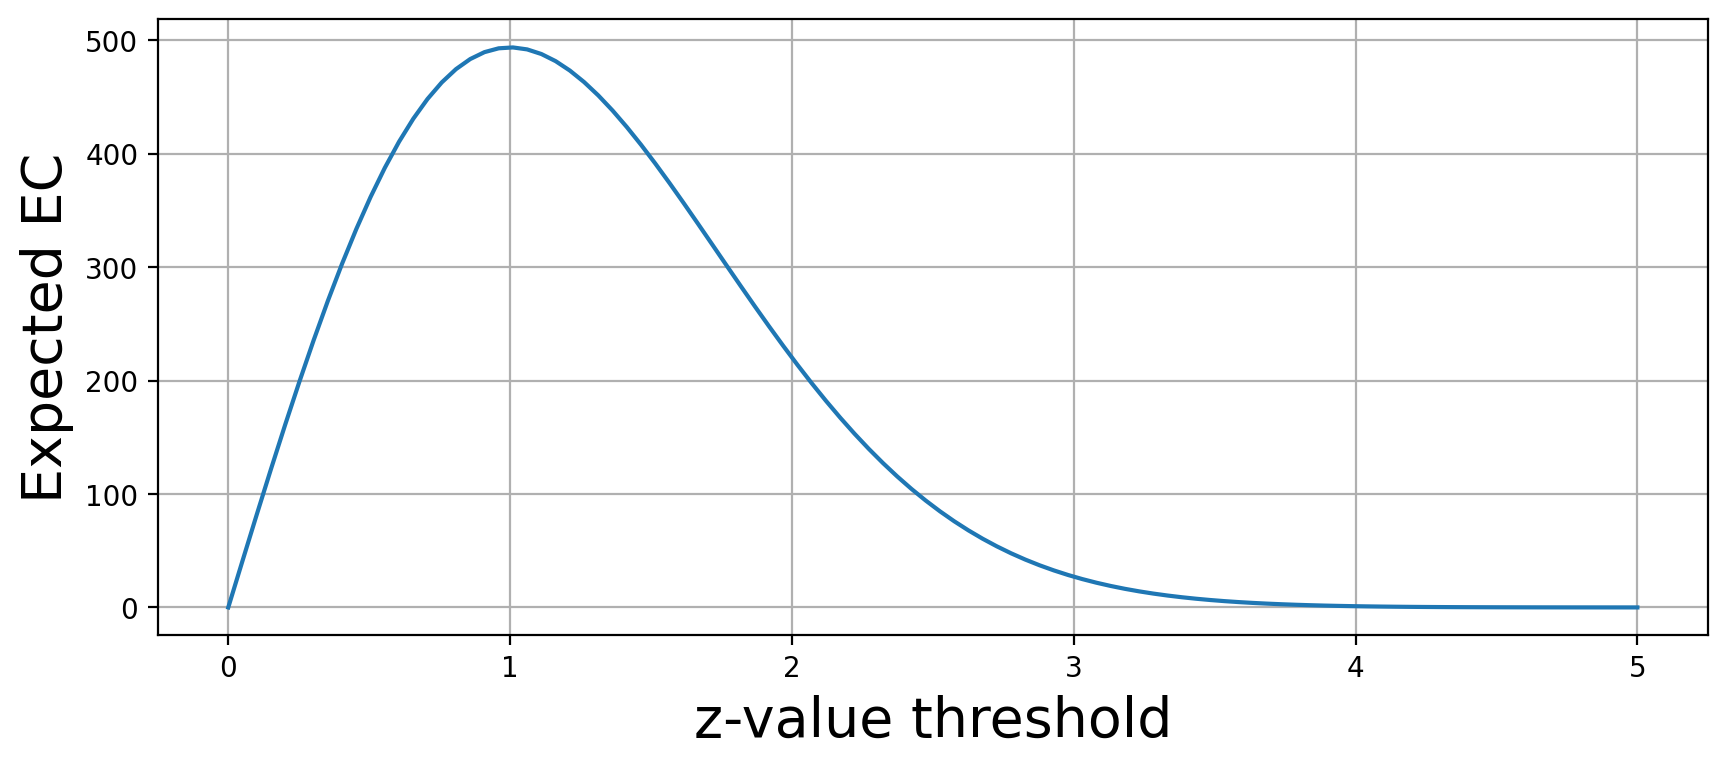

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(zx, ecs)
plt.ylabel('Expected EC', fontsize=20)
plt.xlabel('z-value threshold', fontsize=20)
plt.grid()

To compute the Euler characteristic, we first need to know how to estimate the number of "resels" for our data. You can think of the number of resels as the number of truly independent elements in your data ("resel" is short for "RESolution ELement"). The number of resels is usually estimated by dividing the number of voxels by the estimated size of the resel. For our simulated 2D data, the number of resels is defined as follows:

\begin{align}
N_{resel} = \frac{N_{X}\cdot N_{Y}}{\mathrm{size}_{resel}}
\end{align}

where $N_{X}$ is the number of "voxels" in the first dimension and $N_{Y}$ the number of "voxels" in the second dimension, and where the resel size ($\mathrm{size}_{resel}$) is estimated as the product of the smoothness of our data in all dimensions, measured in FWHM:

\begin{align}
\mathrm{size}_{resel} = \mathrm{FWHM}_{X} \cdot \mathrm{FWHM}_{Y}
\end{align}

So, given a particular size of our resel, $N_{resel}$ represents how many resels there would "fit" in our data.

<div class='alert alert-warning'>
    <b>ToDo</b> (1 point): Usually, the smoothness of the data has to be estimated (usually from the residuals), but in our simulation, we know the smoothness: it's the FWHM we used for our gaussian filter to smooth out data! Compute the number of resels in our simulated data and store it in a variable named <tt>n_resel</tt>.
</div>



In [22]:
# Implement your ToDo here

# YOUR CODE HERE
# number of voxels in the 2D image
n_voxels = data_pvals.size

# compute number of resels (2D → fwhm^2)
n_resel = n_voxels / (fwhm ** 2)
# raise NotImplementedError()

In [23]:
# Feedback for n_resel
if 'n_resel' not in locals():
    print('The variable "n_resel" is not defined. Make sure you compute the number of resels from your data.')
elif not np.isscalar(n_resel):
    print('The number of resels should be a single number, not an array or list.')
elif n_resel <= 0:
    print('The number of resels should be positive. Check your calculation.')
elif n_resel > data.size:
    print('The number of resels is larger than the number of data points, which seems unlikely. Check your calculation.')
else:
    print('The number of resels looks reasonable!')

The number of resels looks reasonable!


Now, another way to interpret EC values is as $p$-values: the chance of finding one or more "blobs" for a given $z$-value! This way, we can choose a particular $z$-value threshold that would correspond to $p = 0.05$. We do this below:

In [24]:
ecs = expected_EC(zx, 278)

# find the index of the EC value closest to alpha
idx_z = np.abs(ecs - alpha).argmin()

# Index the z-values with idx_z
z_thresh = zx[idx_z]
print("The z-value threshold corresponding to p = 0.05: %.3f" % z_thresh)

The z-value threshold corresponding to p = 0.05: 4.444


Now let's plot that.


RFT-based p-threshold: 4.405963702547311e-06


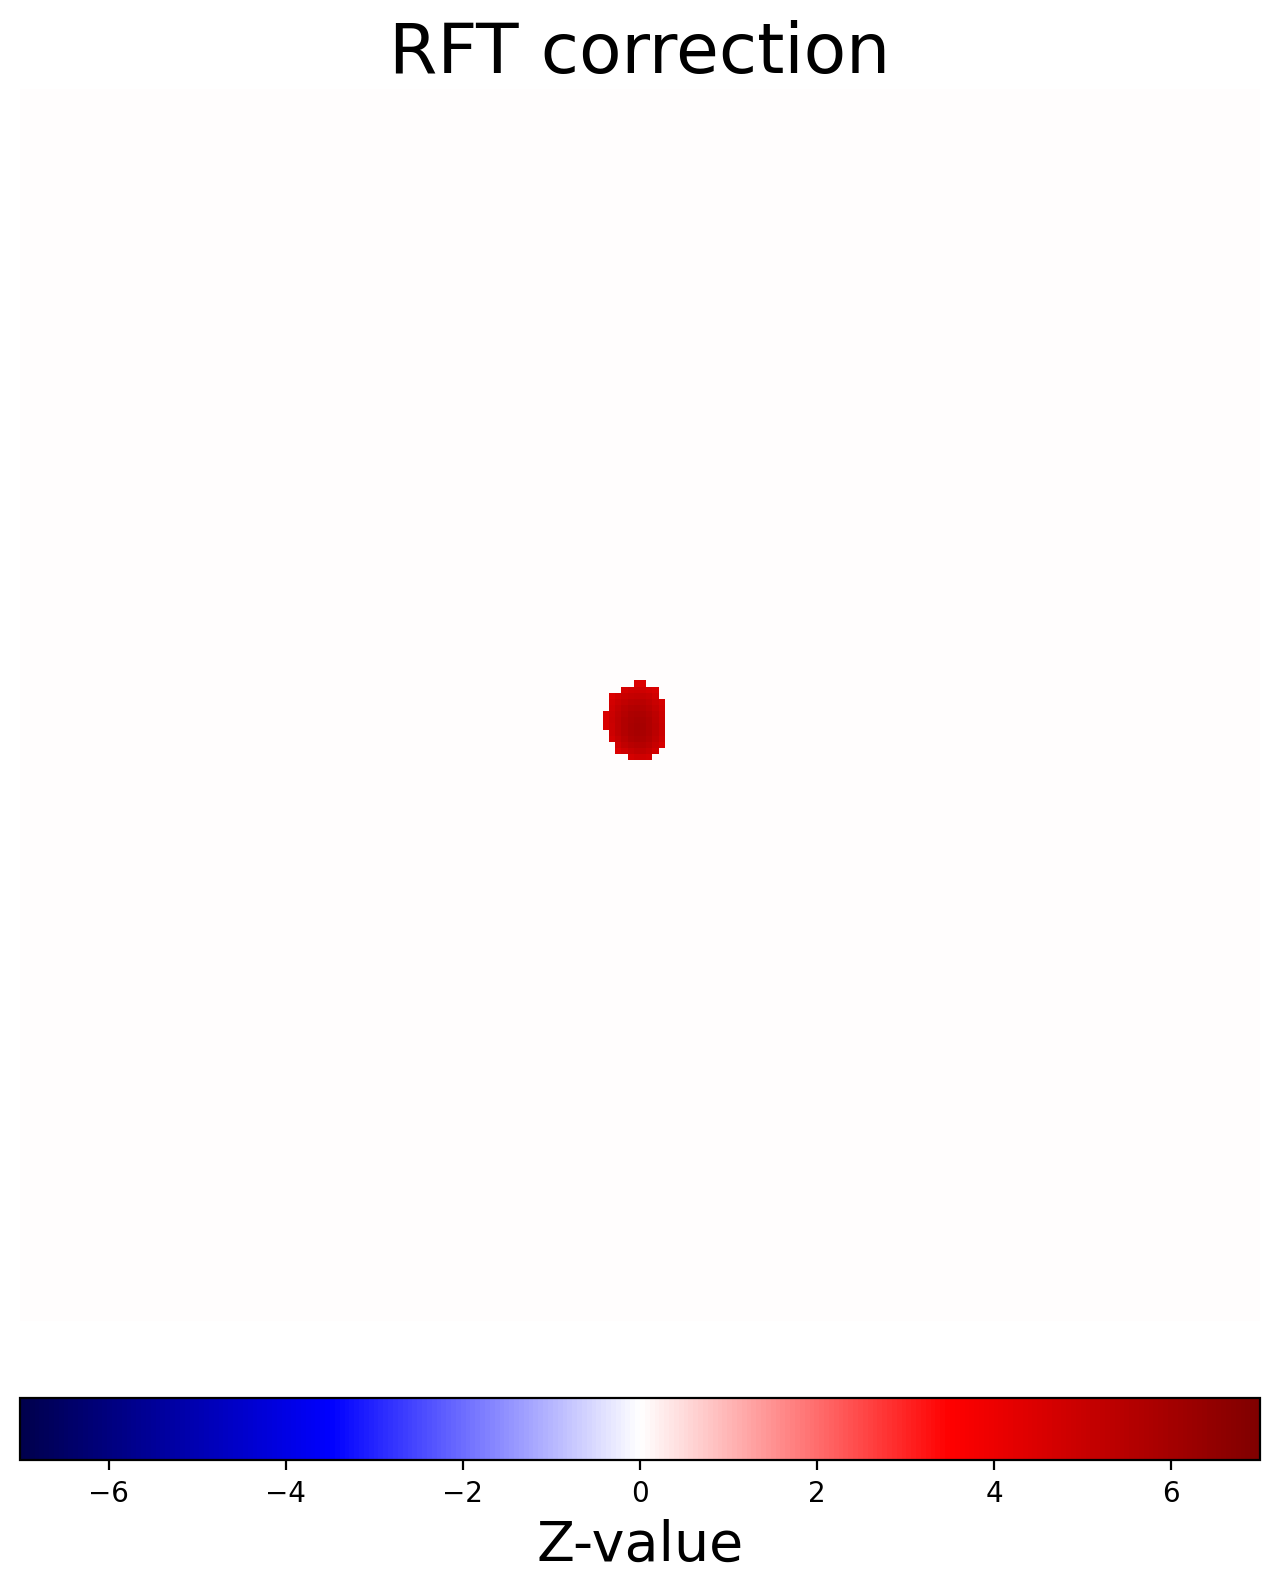

In [25]:
from scipy.stats import norm

# p-value corresponding to the EC-based z-threshold
rft_alpha = 1 - norm.cdf(z_thresh)

print("RFT-based p-threshold:", rft_alpha)

# Create RFT mask
rft_mask = data_pvals < rft_alpha

# Plot
plot_sim_brain(data, mask=rft_mask, title='RFT correction')



<div class='alert alert-info'>
<b>ToThink</b> (1 point): As you (should) see in the plot above, the RTF-based correction is still quite strict/conservative (i.e. misses quite some of the true effect), although arguably not as strict as Bonferroni correction. Given the way how to calculate the number of RESELS, can you think of two ways on how to improve the sensitivity of RFT-based MCC?
</div>

Two ways to improve the sensitivity of RFT\-based MCC are: 

1. increase the spatial smoothness or take a larger FWHM: a larger FWHM means fewer resels \(because resel size ≈ FWHM²\), so doubling the resel size in 2D would reduce the number of resels by a factor of 4. This would reduce the multiple comparisons penalty and improve sensitivity. 
2. reduce the search area or the number of voxels being tested. 



### Cluster-level RFT
In all the previous MCC techniques, we have used voxel-level corrections, which resulting $p$-values tell us something about whether the *height* of a voxel's statistic (often referred to as "amplitude") is higher than would be expected under the null-hypothesis. Basically, because we investigated *per voxel* whether its value is higher than expected, we are making inferences on the level of voxels. 

Another type of inference is *cluster*-level inference, in which you do not test the voxel amplitude, but the *size of clusters*. Basically, in this type of cluster-extent testing, you are investigating whether the size of the clusters you find are (significantly) larger than to be expected under the null-hypothesis (i.e., no effect). 

However, as you can imagine, the null-distribution of cluster sizes (i.e. the size of "significant" clusters you'd expect by chance alone) depends strongly on the initial smoothness of your data. Again: RFT to the rescue! 

Basically, RFT can *also* give us the $p$-value for clusters, given their size, by estimating the null-distribution of cluster-sizes based on the data's smoothness. So, instead of giving us the $p$-value for voxels based on the height of their value and the data's smoothness (i.e., voxel-level RFT), RFT can also do this on the *cluster-level* by investigating the $p$-value of the size of clusters. See how these two RFT-methods relate to each other? They're doing the same thing &mdash; estimating a null-distribution given the smoothness of the data &mdash; but for different things: either for the *height* of the ($z$-)statistic value per voxel (voxel-level RFT) or for the *size* per cluster (cluster-level RFT). 

How RFT does this is way beyond the scope of this course, but we'll walk you through it conceptually, so that you understand the implications of this technique.

Anyway, a first step in cluster-level RFT is to determine a minimum (cutoff) value for your statistics map, which you can use to evaluate whether there are actually clusters in your data. Let's look at an example, in which we use a minimum value of 3.0:

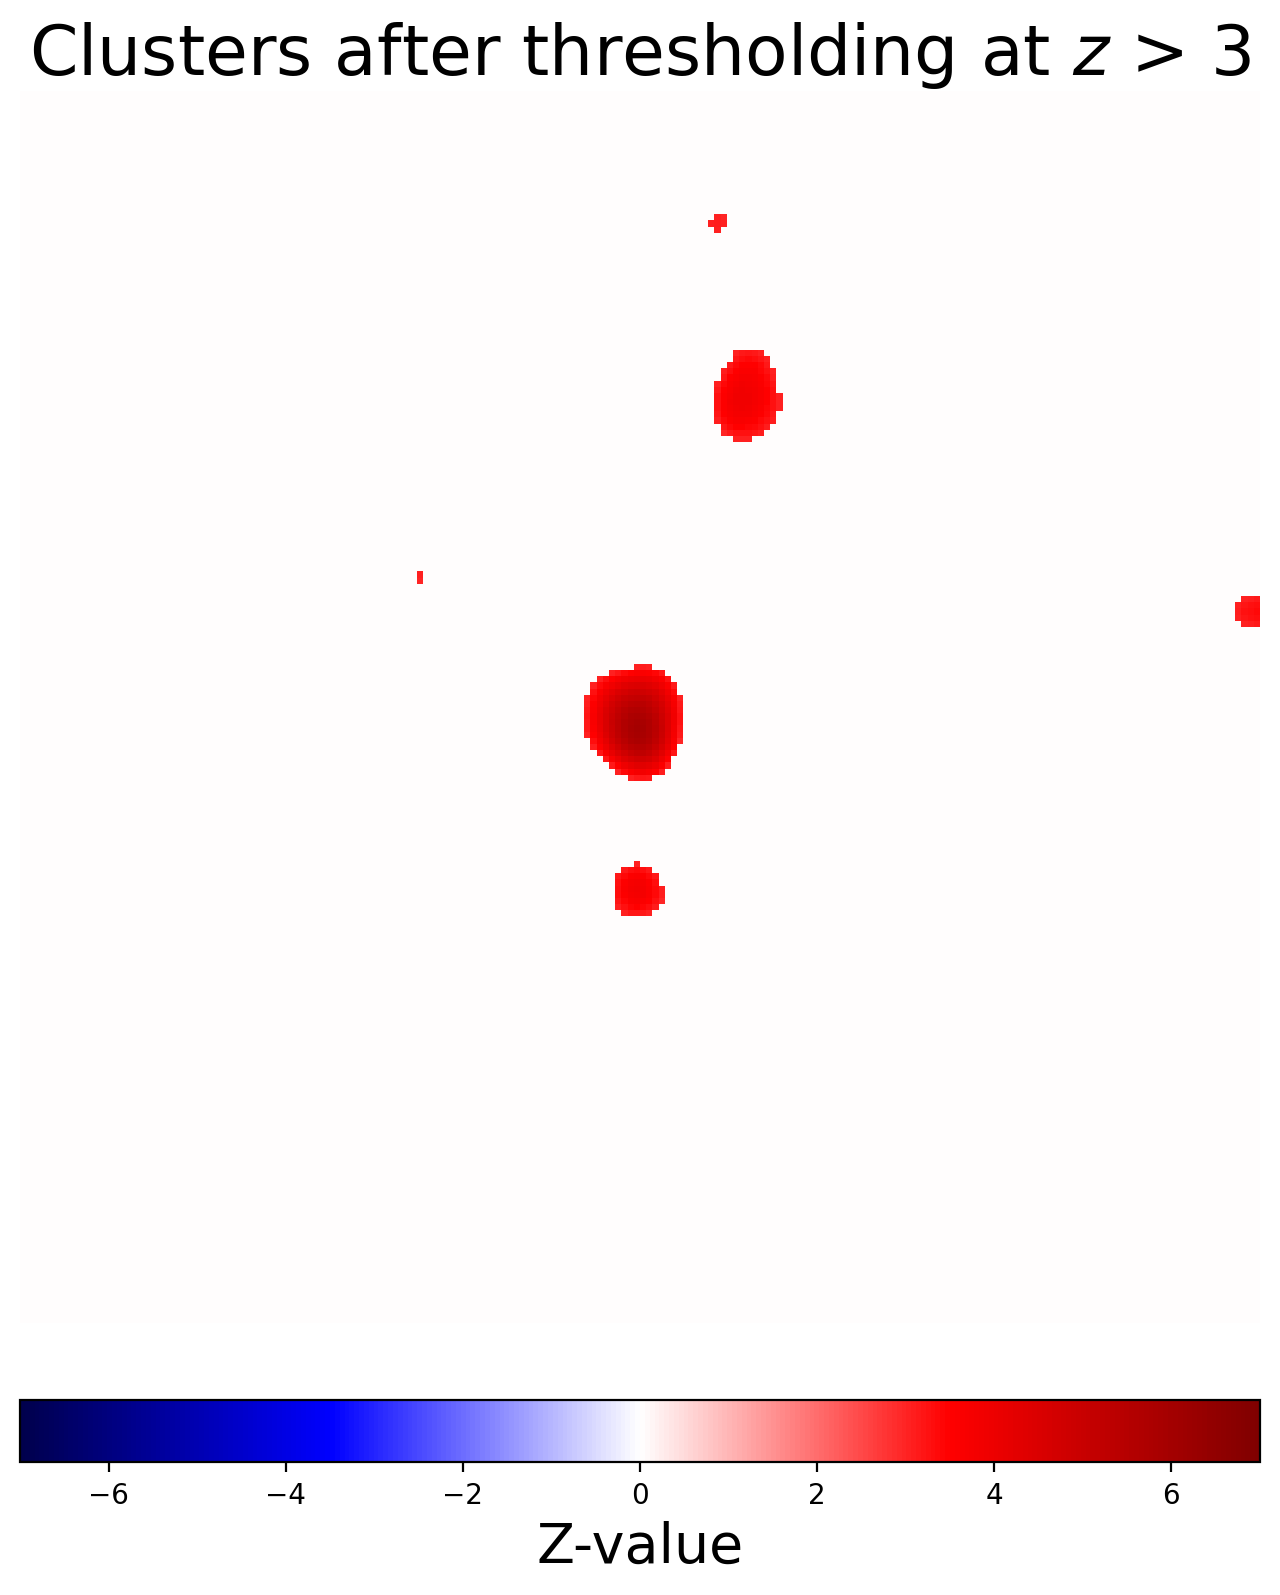

In [26]:
min_z = 3
thresh_data = (data > min_z)

plot_sim_brain(data, mask=thresh_data, title=r"Clusters after thresholding at $z$ > 3")

Now, we can use cluster-based RFT to calculate the $p$-value for each cluster in the above thresholded data plot. This $p$-value reflects the probably of this cluster-size (or larger) under the null-hypothesis. We can then threshold this map with clusters, using a 'cluster-wise' $p$-value cutoff of 0.01 for example, and plot it again to see how this method affects type 1 and type 2 errors. The function below (`threshold_RFT_cluster`) takes three arguments: the statistics-map (our `data` variable), a minimum $z$-value, and a $p$-value cutoff which is used to threshold the clusters.

Below, we do this for a $z$-threshold of 3.1 (corresponding to a $p$-value of approx. 0.001) and a cluster $p$-value threshold of 0.05.

In [27]:
def rft_cluster_threshold(data, z_thresh=3, p_clust=0.05):
    """ This function implements a form of cluster-based
    RFT thresholding. It is based on a non-parametric
    simulation of cluster sizes under the null (with a 
    given smoothness and data shape).
    
    Do not use this for your own analyses. Only works for
    the exact data (smoothness) of the simulation data from
    week 6.
    """
    
    import numpy as np
    from scipy.ndimage import label
    
    clust = np.load('clust_size_dist_data.npz')
    ms, zx = clust['dist'], clust['zx']

    z_idx = np.abs(zx - z_thresh).argmin()
    mask = np.zeros(data.shape, dtype=bool)
    clustered = label(data > z_thresh)[0]
    cluster_ids = np.unique(clustered)[1:]
    for cid in cluster_ids:
        clust_idx = clustered == cid
        c_size = np.sum(clust_idx)
        pval = (np.sum(ms[:, z_idx] > c_size) + 1) / (ms.shape[0] + 1)
        if pval <= p_clust:
            mask[clust_idx] = True
            
    return mask

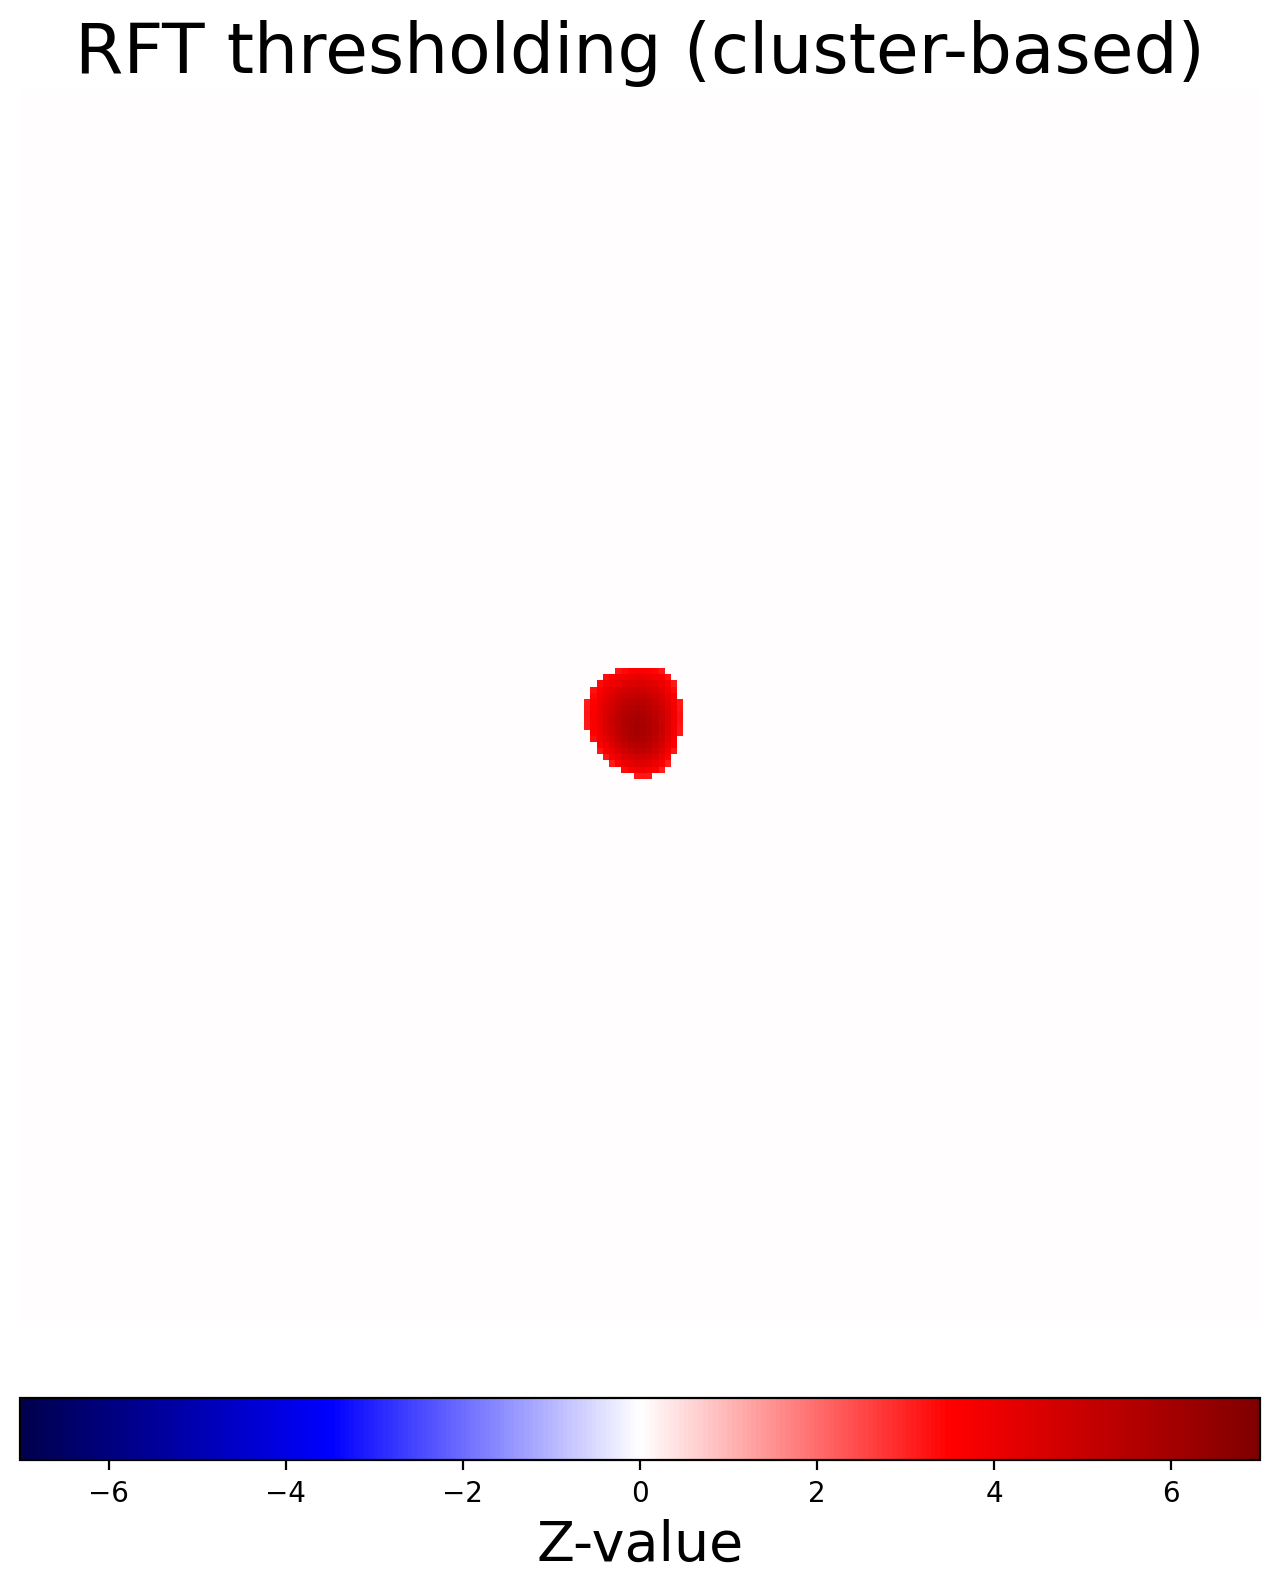

In [28]:
rft_cl_mask = rft_cluster_threshold(data, z_thresh=3.1, p_clust=0.01)
plot_sim_brain(data, mask=rft_cl_mask, title='RFT thresholding (cluster-based)')

From the above plots, you should see that cluster-thresholding can be a very sensitive way to threshold your data if you expect your effects to occur in relatively large clusters (and given that you're able to estimate the smoothness of the data appropriately, something that is a topic of debate). As such, it is by far the most used MCC method in univariate fMRI research today (but this does not necessarily mean it's the *best* way).

## Non-parametric MCC

In addition to the previously discussed MCC approaches \(which are common in parametric group\-level models\), non\-parametric analyses offer another approach. In this approach, the algorithm keeps track of the _maximum_ statistic across permutations. This statistic can refer to the highest voxel\-wise amplitude \(for voxel\-based\), largest cluster size \(for cluster\-based, given some initial $z$\-value cutoff\), or even highest threshold\-free cluster enhanced \(TFCE\)\-transformed amplitude, across permutations.

If we, for example, want to perform a cluster-based non-parametric analyses, we can save the largest cluster size (given some initial $z$-value threshold) for each iteration. Then, across our (let's say) 5000 permutations, we have acquired a *distribution* of maximum cluster sizes under the null hypothesis of no effect. 

We actually did this for our simulated data: we kept track of the maximum cluster size across 1000 permutations given some initial $z$-value cutoff. We'll plot such a non-parametric distribution below (for an arbitrary $z$-value cutoff of 3):



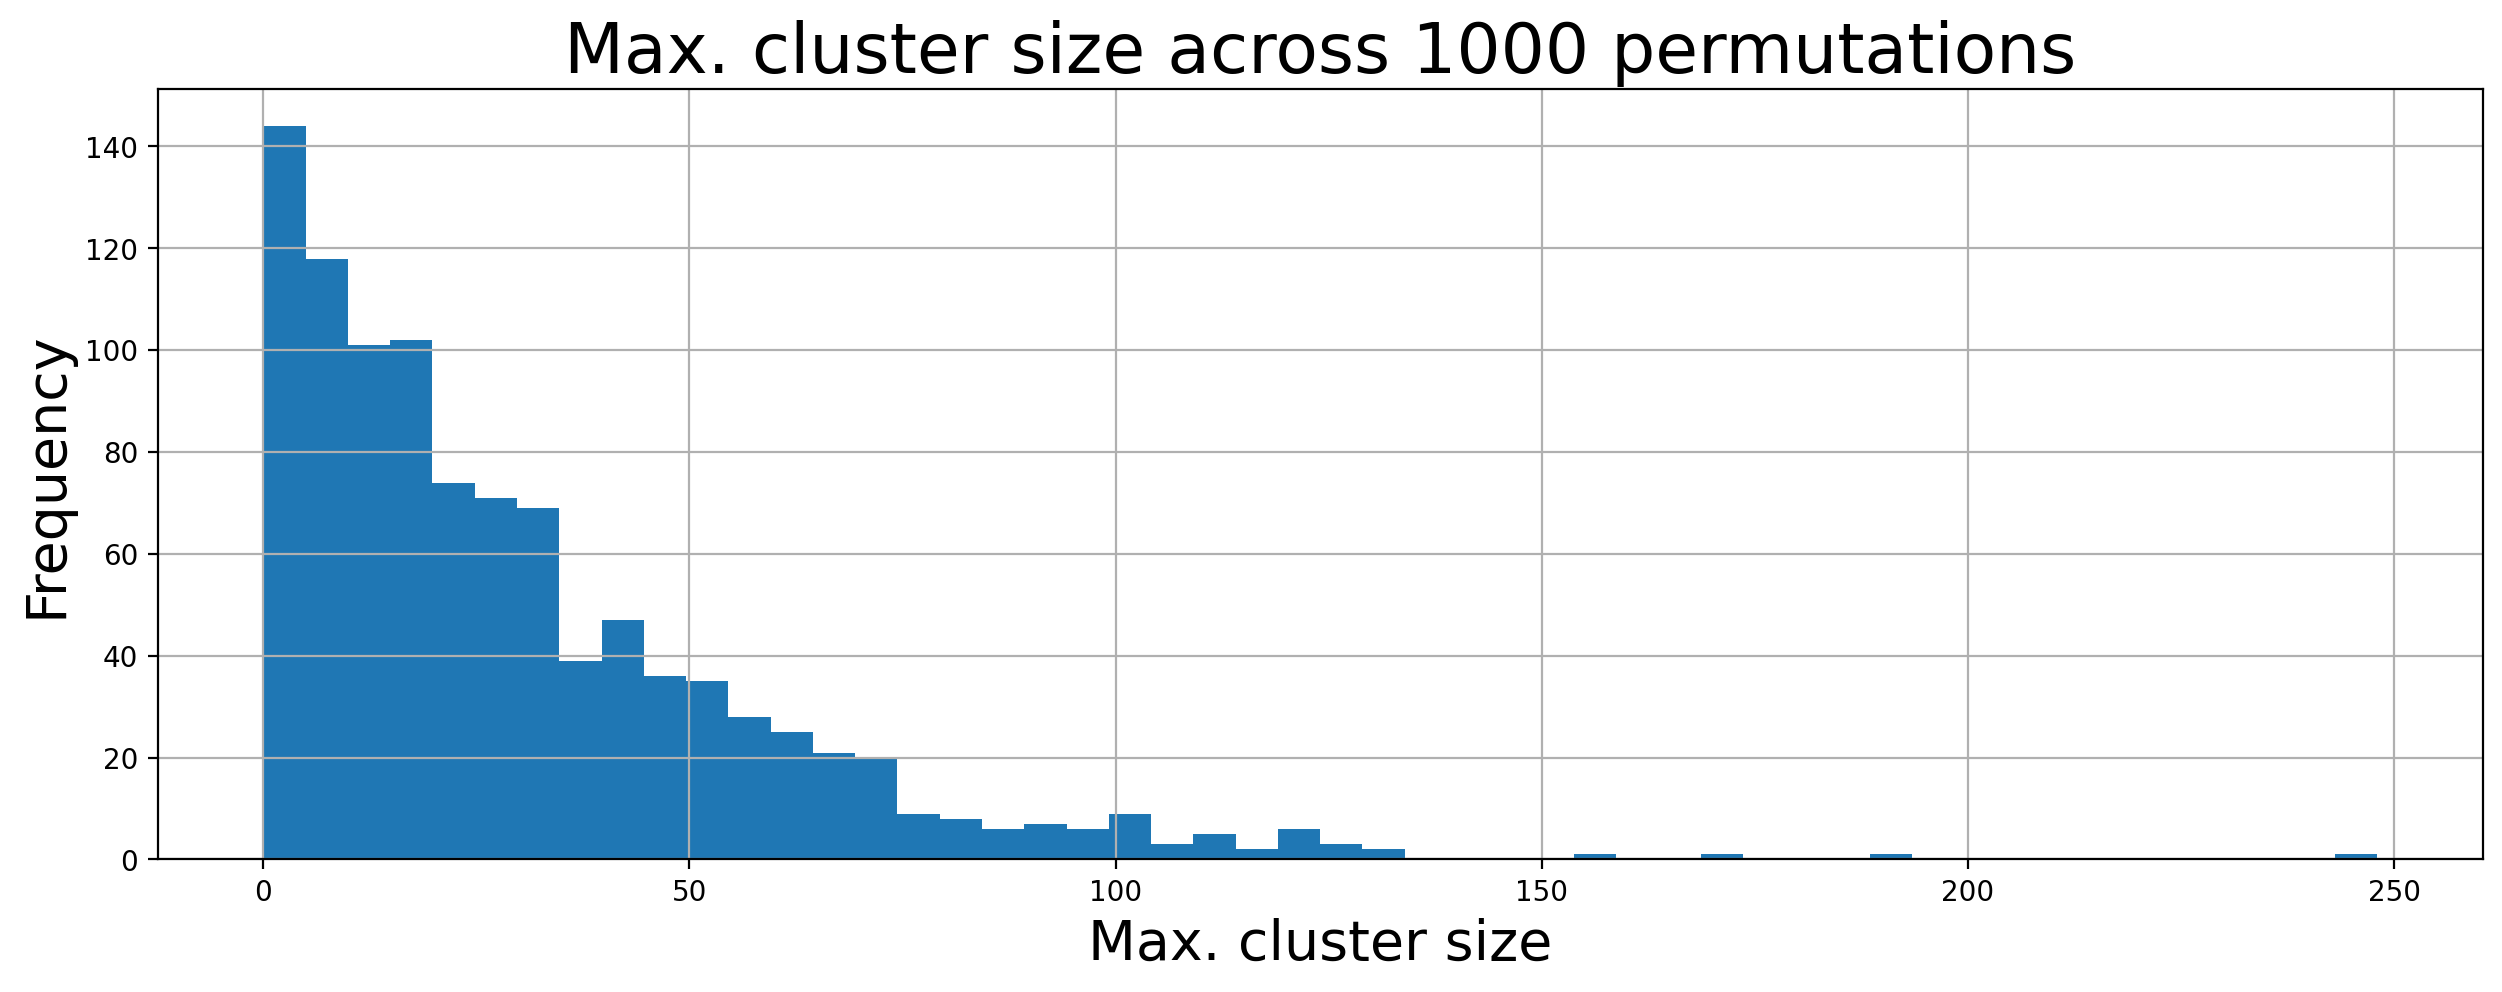

In [29]:
np_dist = np.load('clust_size_dist_data.npz')
zx, clust_sizes = np_dist['zx'], np_dist['dist']
z_cutoff = 3
z_idx = np.abs(zx - z_cutoff).argmin()
clust_size_dist = clust_sizes[:, z_idx]

plt.figure(figsize=(15, 5))
plt.title("Max. cluster size across 1000 permutations", fontsize=25)
plt.hist(clust_size_dist, bins=50)
plt.xlabel("Max. cluster size", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.grid()
plt.show()

With that information, we can calculate the non-parametric $p$-value of each of our *observed* clusters using the same type of formula as we used earlier:

\begin{align}
p_{\mathrm{cluster}} = \frac{\sum_{i=1}^{P}\mathbf{I}(\mathbf{\mathrm{max.\ cluster\ size}}^{\mathrm{perm}}_{i} \geq \mathrm{cluster\ size}^{\mathrm{obs}}) + 1}{P + 1}
\end{align}

Here, the indicator function $\mathbf{I}(\cdot)$ returns 1 when a permutation produces a largest cluster that is at least as big as the cluster we found in the real data, and 0 when it does not. In other words:

$\mathrm{max.\ cluster\ size}^{\mathrm{perm}}_{i}$
= “the size of the biggest cluster in permutation 
𝑖
i”

$\mathrm{cluster\ size}^{\mathrm{obs}}$
= “the size of the cluster we found in the real data”

The numerator therefore counts how many of the permutations produced a largest cluster that was as large as or larger than the one in the real data

In words, this $p$-value reflects how often, under the null hypothesis, we would expect to observe a cluster as large as the one found in our real data simply by chance. Because we compare against the maximum cluster size in each permutation, this procedure automatically corrects for multiple comparisons across the whole image.

The same logic holds for voxel-based (TFCE-transformed) amplitude, where you wouldn't keep track of the maximum cluster size, but the maximum amplitude across permutations.



<div class='alert alert-warning'>
    <b>ToDo</b> (ungraded/optional): Suppose I have found an effect within our simulated data with a cluster size of 231 "voxels" (using an initial $z$-value threshold of 3). Using the distribution of maximum cluster sizes above (i.e., the variable <tt>clust_size_dist</tt>), can you compute the associated cluster $p$-value? Store it in a variable named <tt>pval_clust_size</tt>.
</div> 

In [30]:
# Implement your optional ToDo here

# YOUR CODE HERE
# raise NotImplementedError()

In our experience, non-parametric analyses (e.g., `randomise` in FSL) in combination with TFCE (also supported in FSL) is a very sensitive approach, allowing for voxel-wise inference while taking into account the "blobbiness" of effects!

# ROI analysis

Up until now, we've discussed how to implement "whole\-brain" analyses: models that are applied to _all_ voxels in the brain separately. As we've seen in this notebook, this rather "exploratory" approach leads to issues of multiple comparisons, which are deceptively difficult to properly control for.

One alternative way to deal with the multiple comparisons problem is a more "confirmatory" approach: region\-of\-interest \(ROI\) analysis.


## What is an ROI?
An ROI is a prespecified brain region that is hypothesized to contain the hypothesized effects. These can be anatomically or functionally defined. Anatomical ROIs are regions of interest based on anatomical landmarks (such as folding pattern or histology), for example the caudate nucleus, inferior temporal gyrus, and anterior cingulate cortex.

As opposed to anatomical ROIs, functional ROIs are not based on anatomical properties, but on *functional* properties. These regions are usually determined on other, independent data and analyses. Sometimes, the data used for defining such a functional ROI comes from the same study, which acquired a so-called "functional localizer" in order to define a ROI for analysis of other data. This is also what we did in the NI-edu dataset: we acquired the `floc` runs in order to define functionally-defined "FFA" regions (based on the $\beta_{face} > \mathrm{other}$ contrast) that can be used for ROI-analyses of the `face perception` runs (e.g., to answer questions like: does attractiveness of faces modulate FFA activity?).

In this section, we'll show you how a typical ROI-analysis is done using an anatomical ROI. Then, the section after that will discuss how to derive functional ROIs within a single dataset.

## An example ROI-analysis using an anatomical ROI
For our anatomical ROI-analysis, we'll stick to the `flocBLOCKED` data. Specifically, we will analyze the "face > other" contrast (i.e., $4\cdot \beta_{face} - \beta_{place} - \beta_{body} - \beta_{character} - \beta_{object}$) within the right amygdala (similar to [this study](https://academic.oup.com/scan/article/3/4/303/1628260)). Our group-level hypothesis is that the amygdala activates significantly in response to faces (i.e., a one-sample, one-sided $t$-test): 

* $H_{0}: \beta^{\dagger}_{face > other} = 0$
* $H_{a}: \beta^{\dagger}_{face > other} > 0$

The data that we load in below represents run-level $c\hat{\beta}^{*}$ images corresponding to the "face > other" contrast from our 12 subjects. Data is in MNI152 (2 mm) space with voxel dimensions $[91, 109, 91]$.

In [31]:
import nibabel as nib
cope_4d_img = nib.load('contrast-faceGTother_level-run_stat-cope.nii.gz')
cope_4d = cope_4d_img.get_fdata()
print("Shape of data: %s" % (cope_4d.shape,))

Shape of data: (91, 109, 91, 12)


Let's visualize this data. We'll plot (using `plt.imshow`) a single (right-hemisphere) sagittal slice of each subjects' COPE-image, with red indicating positive contrast-values (i.e., $4\cdot \beta_{face} - \beta_{place} - \beta_{body} - \beta_{character} - \beta_{object} > 0$) and blue indicating negative contrast-values (i.e., $4\cdot \beta_{face} - \beta_{place} - \beta_{body} - \beta_{character} - \beta_{object} < 0$).

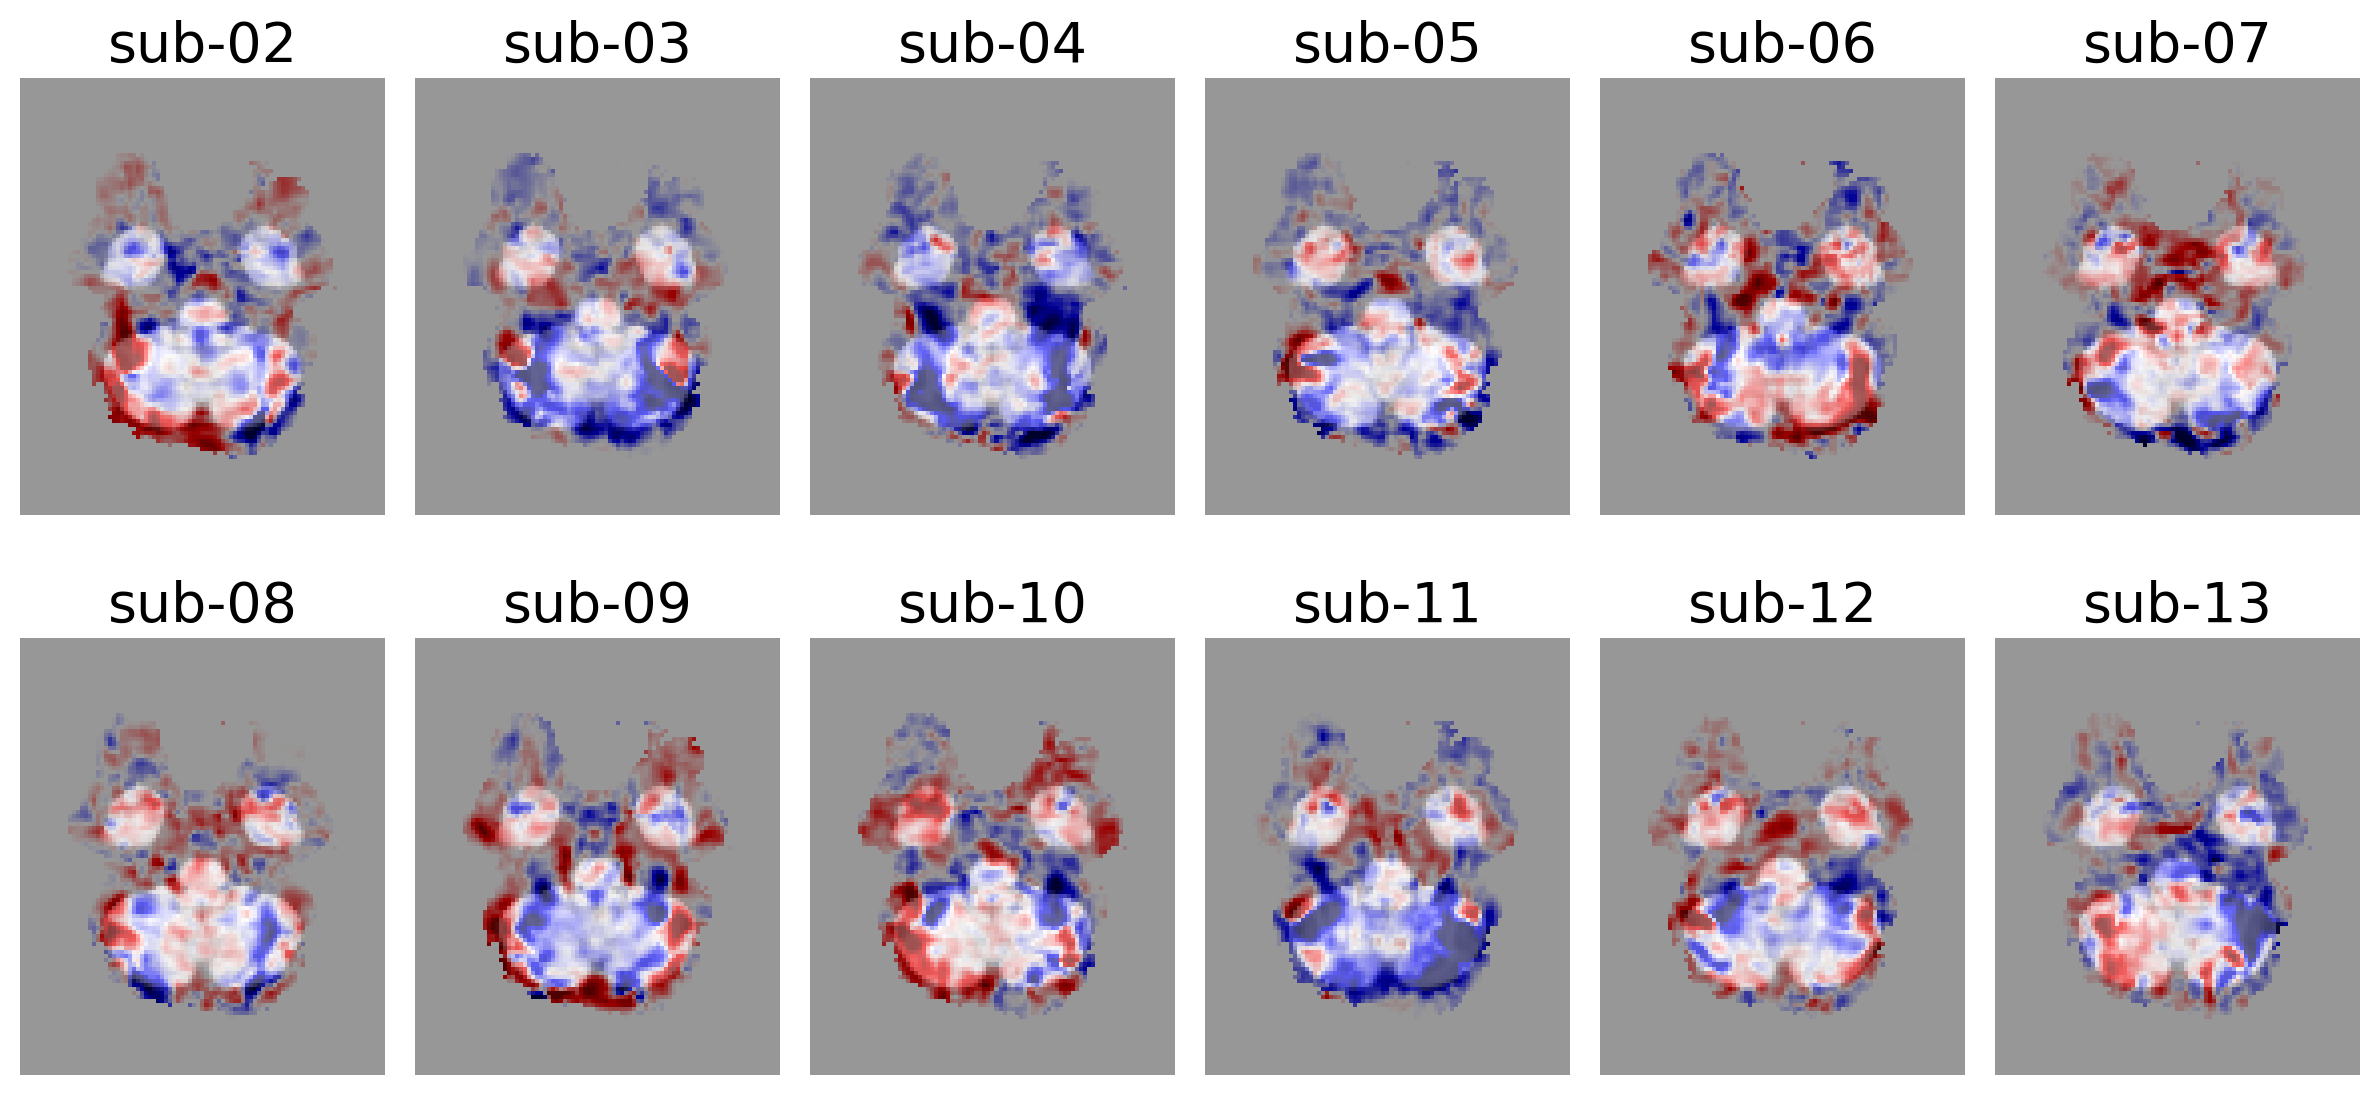

In [32]:
import matplotlib.pyplot as plt
from nilearn.datasets import load_mni152_template
from skimage.transform import resize

mni = load_mni152_template().get_fdata()
subjects = ['sub-%s' % str(i).zfill(2) for i in range(2, 14)]
plt.figure(figsize=(12, 6))

for i in range(cope_4d.shape[-1]):
    plt.subplot(2, 6, i+1)
    plt.title(subjects[i], fontsize=20)
    mni_slice = mni[:, :, 26]
    cope_slice = cope_4d[:, :, 26, i]
    mni_resized = resize(mni_slice, cope_slice.shape, preserve_range=True)
    plt.imshow(mni_resized.T, origin='lower', cmap='gray')
    plt.imshow(cope_slice.T, cmap='seismic', origin='lower',vmin=-500, vmax=500, alpha=0.6)
    plt.axis('off')
plt.tight_layout()
plt.show()


Now, conventional (exploratory) whole-brain analysis would fit a GLM on each voxel separately, but for our ROI-analysis, we're going to do it differently: we're only going to analyze the across-voxel average lower-level $c\hat{\beta}^{*}$ values within the right amygdala.

We'll load in the right amygdala mask first. This is a region from the probabilistic Harvard-Oxford subcortical atlas.

In [33]:
amygdala_probmask_img = nib.load('amygdala_lat-right_atlas-harvardoxford_thresh-0.nii.gz')
amygdala_probmask = amygdala_probmask_img.get_fdata()
print("Shape of probabilistic amygdala mask: %s" % (amygdala_probmask.shape,))

Shape of probabilistic amygdala mask: (91, 109, 91)


<div class='alert alert-warning'>
<b>ToDo</b> (3 points): We now have the data (of shape $91 \times 109 \times 91 \times 12$) and a mask (of shape $91 \times 109 \times 91$). In this assignment, you'll implement the actual ROI analysis using this data.

You have to do the following:

1. Create a boolean mask (array with <tt>True</tt>/<tt>False</tt> values) by tresholding the probabilitic mask at 20 (i.e., $p(\mathrm{amygdala}) \geq 0.2$). There should be 549 voxels surviving this threshold;
2. Average, per subject, the $c\hat{\beta}^{*}$ values within this mask. You *do not* need a for-loop for this (hint: numpy broadcasting!);
3. Set up an appropriate group-level design matrix ($\mathbf{X}^{\dagger}$) that allows you to compute the average effect ($\beta^{\dagger}$) across the 12 ROI-average values ($y^{\dagger}$) and run a GLM;
4. With an appropriate group-level contrast, compute the $t$-value and $p$-value associated with our group-level hypothesis (outlined in the beginning of this section).

Store the ROI-average values (in total 12) as a numpy array in a variable named <tt>y_group</tt>, your group-level design matrix (a $12 \times 1$ numpy array) in a variable named <tt>X_group</tt>, your group-level parameter (there should be only one) in a variabled named <tt>beta_group</tt>, and your $t$-value and $p$-value in variables named <tt>t_group</tt> and <tt>p_group</tt> respectively. You can use the <tt>stats.t.sf</tt> function to calculate the <em>one-sided</em> $p$-value from your $t$-value.

</div>



In [34]:
# Implement the above ToDo here (step 1 and 2)
import numpy as np

# YOUR CODE HERE

# 1. boolean mask thresholded at 20
roi_mask = amygdala_probmask >= 20
print("nr of voxels in mask:", np.sum(roi_mask))

# 2. average values per subject within mask
data_masked = cope_4d[roi_mask, :]    
y_group = data_masked.mean(axis=0)    
print("y_group.shape:", y_group.shape)
# raise NotImplementedError()

nr of voxels in mask: 549
y_group.shape: (12,)


In [35]:
# Feedback steps 1-2

if 'y_group' not in locals():
    print('The variable "y_group" is not defined. Make sure you create an array named "y_group".')
elif not isinstance(y_group, np.ndarray):
    print('y_group should be a numpy array, not a list or other type.')
elif y_group.shape[0] != 12:
    print(f'y_group should have 12 elements (one per subject), but it has shape {y_group.shape}.')
elif np.any(np.isnan(y_group)):
    print('y_group contains NaN values. Check your mask and averaging procedure.')
elif (y_group < -1e5).any() or (y_group > 1e5).any():
    print('Some values in y_group are unusually large. Check your calculations.')
else:
    print('y_group looks reasonable!')

y_group looks reasonable!


In [36]:
# Implement the above ToDo here (step 3)

# YOUR CODE HERE
# group level design matrix
X_group = np.ones((12, 1))

# group level parameter
beta_hat = np.linalg.inv(X_group.T @ X_group) @ (X_group.T @ y_group)
beta_group = np.array([beta_hat[0]]) # making it a scalar   

# raise NotImplementedError()

In [37]:
# Feedback step 3

if 'X_group' not in locals():
    print('The variable "X_group" is not defined. Make sure you create your group-level design matrix.')
elif not isinstance(X_group, np.ndarray):
    print('X_group should be a numpy array.')
elif X_group.shape[0] != 12 or X_group.shape[1] != 1:
    print(f'X_group should have shape (12, 1), but has shape {X_group.shape}.')
else:
    print('X_group looks reasonable!')

if 'beta_group' not in locals():
    print('The variable "beta_group" is not defined. Make sure you compute the group-level parameter estimate.')
elif not isinstance(beta_group, np.ndarray):
    print('beta_group should be a numpy array.')
elif beta_group.size != 1:
    print(f'beta_group should have a single value, but has shape {beta_group.shape}.')
elif np.isnan(beta_group).any():
    print('beta_group contains NaN. Check your GLM calculation.')
else:
    print('beta_group looks reasonable!')

X_group looks reasonable!
beta_group looks reasonable!


In [38]:
# Implement the above ToDo here (step 4)
from scipy import stats

# YOUR CODE HERE

# other parameters 
y_hat = (X_group @ np.array([[beta_group]])).ravel() # residuals
residuals = y_group - y_hat
df = 12 - 1 # df
s2 = (residuals @ residuals) / df # residual variance
se_beta = np.sqrt(s2 / (X_group.T @ X_group))[0,0] # standard error

# t and p values
t_group = beta_group[0] / se_beta
p_group = stats.t.sf(t_group, df)
print("t_group:", t_group)
print("p_group (one-sided):", p_group)
# raise NotImplementedError()

t_group: 3.909832118812115
p_group (one-sided): 0.0012175186972328278


In [39]:
# Feedback step 4

if 't_group' not in locals():
    print('Variable "t_group" is not defined. Make sure you compute the t-value.')
elif 'p_group' not in locals():
    print('Variable "p_group" is not defined. Make sure you compute the p-value.')
elif not np.isscalar(t_group):
    print('t_group should be a single number (scalar).')
elif not np.isscalar(p_group):
    print('p_group should be a single number (scalar).')
elif t_group <= 0:
    print('Your t_group value seems non-positive. Check your contrast and GLM calculation.')
elif not (0 < p_group < 1):
    print('Your p_group value is outside [0, 1]. Check how you computed the one-sided p-value.')
else:
    print('t_group and p_group look reasonable!')

t_group and p_group look reasonable!


## Functional ROIs & neurosynth
In addition to anatomical ROIs, you can also restrict your analyses to functionally defined ROIs. "Functionally defined", here, means that the region has been derived from or determined by its assumed function. This can be done using a (separate) dataset specifically designed to localize a particular functional region (the "functional localizer" approach). Another option is to define your ROI based on a meta-analysis on a particular topic. For example, you could base your ROI on (a set of) region(s) on a meta-analysis of the neural correlates of face processing.

One particular uesful tool for this is [neurosynth](https://neurosynth.org/) (see also the associated [article](https://www.nature.com/articles/nmeth.1635)). Neurosynth is a tool that, amongst other things, can perform "automatic" meta-analyses of fMRI data. As stated on its [website](https://neurosynth.org/), "it takes thousands of published articles reporting the results of fMRI studies, chews on them for a bit, and then spits out images" that you can use, for example, a functional ROIs.

<div class='alert alert-warning'>
    <b>ToDo</b> (ungraded): Go to <a href="https://neurosynth.org">https://neurosynth.org</a> and read through the text on its homepage. Then, click on "Meta-analyses" &rarr; "Terms". Here, you can search for a particular term that you want Neurosynth to compute the meta-analysis for. For example, in the search bar on the right, fill in the term "face", and you should see a list of "face" related terms (e.g., "emotional faces", "face", "face ffa", "face recognition", etc.). 

Now, click on the term "emotional faces".
</div>

After selecting a particular term, Neurosynth will open a new page with an interactive image viewer. By default, it shows you the result (i.e., $z$-values) of an "association test" of your selected term across voxels, which tests whether voxels are *preferentially* related to your selected term (click on "FAQs" for more information). 

<div class='alert alert-warning'>
    <b>ToDo</b> (ungraded): Under "Thresholds", move the right slider up and down to adjust the $z$-value threshold of the association test values, which should immediately update the images on the right. 
</div>

<div class='alert alert-warning'>
    <b>ToDo</b> (ungraded): Click on "Studies" to view the studies that Neurosynth based this meta-analysis on. You'll see that the exact topic differs across studies (from face processing in alcohol use disorder to the role of expectations in face processing), but the term ("face processing") is common to all studies.
</div>

<div class='alert alert-warning'>
    <b>ToDo</b> (ungraded): Now, suppose that I believe that perceiving faces is intrisically rewarding, because humans are social animals, and I want to see whether perceiving faces (relative to other types of images) significantly activates the brain's reward circuitry.

Conduct a meta-analysis using the term "reward", set the threshold to $z > 12$ (note that this exact value is somewhat arbitrary; make sure to decide on this cutoff *before* looking at your own data as to avoid circularity in your analysis!). Download this thresholded map by clicking on the download symbol (next to the trash bin icon) next to "reward: association test". This will download a nifti file *to your own computer*.

If you're working on a Jupyterhub instance, upload this image as follows:

* Under the "Files" tab in Jupyterhub, navigate to your <tt>week_6</tt> folder (with your mouse);
* Click on the "Upload" button, select the downloaded file (<tt>reward_association-test_z_FDR_0.01.nii.gz</tt>), and click on the blue "Upload" button to confirm.

</div>



Although slightly off-topic, another great Neurosynth functionality is its "decoder". As opposed to its meta-analysis functionality which generates the most likely (and specific) brain map given a particular term, the decoder produces the most likely terms given a particular (untresholded) brain map! This is great way to help you interpret your (whole-brain) results (but this does *not* replace a proper and rigorous experimental design).

<div class='alert alert-warning'>
    <b>ToDo</b> (ungraded/optional): To use the decoder, click on the "Decoder" tab on the Neurosynth website and subsequently on the "Upload an Image" button. This will redirect you to another website, <a href="https://neurovault.org">Neurovault</a>. You'll have to create an account on Neurovault in order to use Neurosynth's decoder (if you don't want to, that's fine, as this is an optional ToDo).

In this week's directory (<tt>week_6</tt>), we included the unthresholded $z$-value map from the group-level (mixed-effects) analysis of the $4\cdot \beta_{face} - \beta_{place} - \beta_{body} - \beta_{character} - \beta_{object}$ contrast: <tt>contrast-faceGTother_level-group_stat-zstat.nii.gz</tt>. You need to download this file to your computer, which you can do by navigating to your <tt>week_6</tt> directory in Jupyterhub, selecting the file, and clicking on "Download". Now, let's decode this image.

After registration on the Neurovault website, you should be redirected to a short "questionnaire" where you have to fill in some metadata associated with the image. Give it a name (e.g., "FFA localizer"), add it to a particular "collection" ("{your username} temporary collection" is fine), set the map type to "Z map", set the modality & acquisition type to "fMRI-BOLD", and "Cognitive Atlas Paradigm" to "face recognition task" (this is unimportant for now). Finally, under "File with the unthresholded volume map", select the just downloaded file and click "Submit" at the very bottom.

You should be redirected to "Neurosynth", which should now visualize our group-level "face > other" $z$-statistic file. Now, at the bottom of the page, you find a table with "Term similarity", showing the terms whose unthresholded brain maps correlate the most with our just uploaded brain map. Scrolling through these terms, you'll notice a lot of terms associated with the "default mode network" (DMN)! We are not sure why our "face map" correlates so highly with the brain map typically associated with the DMN ... One reason might be that faces deactivate the DMN *less* than the other conditions (bodies, places, etc.), which shows up as a positive effect in the "face > other" contrast. 

</div>

Alright, let's get back to the topic of functional ROIs again. Given that you defined a functional ROI, the process of analyzing your data proceeds in the same fashion as with anatomical ROIs:
1. You average your lower-level data ($c\hat{\beta}^{*}$) within your ROI;
2. You construct a group-level design matrix and run a GLM;
3. Proceed as usual (construct group-level contrats, calculate $t$/$z$-values, etc.)

### 🎉 Well done! 

<div class='alert alert-success'>
    <b>Tip</b>: When you are finished with your work, click "Validate" at the top of the notebook. This will run the entire notebook and tell you with there are any errors.
</div>